# Chocolate Sales 2023–2024 — Exploratory Data Analysis

**Course:** Applied Data Science, Bar-Ilan University — Final Project
**Team:** Yonatan K · Oz P · Bar A
**Dataset:** [Chocolate Sales Dataset 2023–2024](https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024) (Kaggle, v2) — 1,000,000 transactions across 200 products, 100 stores and 50,000 customers.

**Reading contract.** This notebook is organised as *question → evidence → interpretation*. Because the sample is large (n ≈ 10⁶), null-hypothesis p-values are essentially zero for even microscopic departures from the null; we therefore lead every claim with an **effect size** (Cliff's δ, Cramér's V, η², ε², partial r) and treat p-values as a formality. Statistical helpers live in `src/` so the notebook stays narrative.

## 0 · Setup & reproducibility

All randomness is fixed (`random_state=42`). Heavy logic is imported from `src/`:
`data_loading.py` (acquisition, star-schema assembly, integrity checks), `stats_utils.py`
(effect sizes, FDR, bootstrap), `plotting.py` (styling).

In [27]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
from src import data_loading as dl
from src import stats_utils as su
from src.plotting import set_style, annotated_heatmap, barh_effect_sizes

set_style()
SEED = 42
np.random.seed(SEED)

print("versions:", "pandas", pd.__version__, "| numpy", np.__version__,
      "| scipy", __import__("scipy").__version__, "| seaborn", sns.__version__)

versions: pandas 3.0.3 | numpy 2.5.1 | scipy 1.18.0 | seaborn 0.13.2


## 1 · Problem definition & analytical questions

A chocolate retail chain operates 100 stores of three types (Retail / Airport / Online) in six
countries, selling a 200-product catalogue to 50,000 registered customers over 2023–2024. Each of
the 10⁶ rows is one order line: quantity, unit price, discount, and the resulting revenue, cost and
profit.

The EDA is driven by six questions, each answered in a dedicated section:

| # | Question | Section |
|---|----------|---------|
| Q1 | Is the data trustworthy — complete, internally consistent, and what are its provenance limits? | §2–§3 |
| Q2 | What does each variable look like alone, and which raw "correlations" are real vs. accounting tautologies? | §4–§6 |
| Q3 | **Are discounts profitable?** Does the volume lift cover the margin give-away (price elasticity)? | §7 |
| Q4 | Do loyalty members, demographics, store types or geographies differ in value — by how much? | §7 |
| Q5 | Is demand seasonal / periodic, and at which time scales? | §8 |
| Q6 | Do customers/products/stores form natural segments we can act on? | §9 |

The end product of the EDA is a ranked insight table (§11) and a modelling brief (§12) that feeds
the prediction phase of the project.

## 2 · Data acquisition, schema & integrity audit

The dataset is a classic **star schema**: a `sales` fact table with foreign keys into three
dimensions — `products` (200 × 6: brand, category, cocoa %, weight), `stores` (100 × 5: city,
country, type) and `customers` (50,000 × 5: age, gender, loyalty flag, join date). An auxiliary
`calendar` table (731 days) ships with v2.

Acquisition is programmatic via `kagglehub` (cached locally after the first run), so the raw data
never enters the repository — as required by the course submission rules.

In [28]:
data_dir = dl.download_dataset()
tables = dl.load_tables(data_dir)
calendar = dl.load_calendar(data_dir)

for name, t in tables.items():
    print(f"{name:<10} {t.shape[0]:>9,} rows × {t.shape[1]} cols")
print(f"{'calendar':<10} {len(calendar):>9,} rows × {calendar.shape[1]} cols" if calendar is not None else "calendar   (absent)")

sales      1,000,000 rows × 11 cols
products         200 rows × 6 cols
stores           100 rows × 5 cols
customers     50,000 rows × 5 cols
calendar         731 rows × 6 cols


### 2.1 Column-level quality audit

For every table: missingness, duplicate rows, and dtype sanity. For the fact table we also check
*domain validity* — non-negative quantities and money columns, and discounts confined to [0, 1].

In [29]:
def quality_report(name, t):
    na = t.isna().sum().sum()
    print(f"=== {name} === {t.shape[0]:,}×{t.shape[1]} | duplicates: {t.duplicated().sum():,} | missing cells: {na:,}")
    if na:
        miss = t.isna().mean().mul(100)
        print(miss[miss > 0].sort_values(ascending=False).round(3).to_string())

for name, t in tables.items():
    quality_report(name, t)

s = tables["sales"]
print("\nsales domain validity:")
print("  quantity >= 1:", bool((s.quantity >= 1).all()),
      "| money cols >= 0:", bool((s[["unit_price", "revenue", "cost", "profit"]] >= 0).all().all()),
      "| discount in [0,1]:", bool(s.discount.between(0, 1).all()))
print("  distinct discount levels:", sorted(s.discount.unique()))
print("  quantity support:", dict(s.quantity.value_counts().sort_index()))

=== sales === 1,000,000×11 | duplicates: 0 | missing cells: 0
=== products === 200×6 | duplicates: 0 | missing cells: 0
=== stores === 100×5 | duplicates: 0 | missing cells: 0
=== customers === 50,000×5 | duplicates: 0 | missing cells: 0

sales domain validity:
  quantity >= 1: True | money cols >= 0: True | discount in [0,1]: True
  distinct discount levels: [np.float64(0.0), np.float64(0.1), np.float64(0.15), np.float64(0.2)]
  quantity support: {1: np.int64(199923), 2: np.int64(199970), 3: np.int64(200330), 4: np.int64(200149), 5: np.int64(199628)}


**Interpretation.** The audit is unusually clean: zero missing cells, zero duplicate rows, and all
domain constraints hold across 10⁶ transactions. Two structural facts matter downstream:

1. **`discount` is not continuous** — it takes exactly four values {0, 0.10, 0.15, 0.20}, with a
   large point-mass at 0. Treating it as a continuous regressor would be a specification error; we
   will model it as an ordered factor (*no discount / 10% / 15% / 20%*) throughout.
2. **`quantity` is uniform on {1,…,5}** (each level ≈ 200 K rows, ≈ 0.1% spread). A marginally
   uniform basket size is not what organic purchase data looks like (typically geometric-ish,
   mode 1); this is the first hint about provenance, examined formally in §3.

### 2.2 Referential integrity

A star schema is only as good as its joins: any fact row whose foreign key is missing from a
dimension silently disappears under an inner join. We quantify that loss *before* merging.

In [30]:
ri = dl.referential_integrity(tables)
print(ri.to_string(index=False))

orphan_ids = sorted(s.loc[~s.product_id.isin(tables["products"].product_id), "product_id"].unique())
print("\norphan product ids:", orphan_ids)
print("catalogue id range :", tables["products"].product_id.min(), "…", tables["products"].product_id.max(),
      f"({len(tables['products'])} products)")

dimension         key  orphan_rows  orphan_pct  distinct_orphan_keys
 products  product_id         9764      0.9764                     2
   stores    store_id            0      0.0000                     0
customers customer_id            0      0.0000                     0

orphan product ids: ['P0000', 'P0201']
catalogue id range : P0001 … P0200 (200 products)


**Interpretation.** 9,764 rows (0.98%) reference products outside the catalogue — and the offending
keys are precisely **`P0000` and `P0201`**, the two integers flanking the valid range
P0001–P0200. This is a textbook *boundary (off-by-one) artifact* of the data generator, not a
business phenomenon. Because the affected rows are selected by a mechanism unrelated to any
observed outcome, dropping them is ignorable (MCAR-by-construction): an inner join discards <1% of
rows and cannot bias downstream estimates. Store and customer keys are fully consistent.

### 2.3 The accounting identities — why the "obvious" correlations are tautologies

`revenue`, `cost` and `profit` are not independent measurements; they are *derived columns*. We
verify the two defining identities to numerical precision:

$$\text{revenue} = \text{quantity} \times \text{unit\_price} \times (1 - \text{discount}), \qquad
\text{profit} = \text{revenue} - \text{cost}$$

In [31]:
print(dl.identity_residuals(s).to_string(index=False))

                    identity  max_abs_residual  share_within_1_cent
revenue = qty*price*(1-disc)             0.005              1.00000
     profit = revenue - cost             0.010              0.96424


**Interpretation.** Both identities hold to within rounding (max residual ≤ 1 cent, consistent with
prices stored at 2 decimals). The consequence is important: any Pearson correlation among
{quantity, unit_price, revenue, cost, profit} — e.g. r(revenue, cost) ≈ 0.98 — is an **algebraic
consequence of the schema**, not a discovery. An earlier draft of this analysis presented exactly
those pairs as its headline findings; a correlation between a sum and its parts carries zero
scientific content. From §5 onward we therefore analyse **derived economics** that are *not*
determined by the identities: **profit margin** (profit/revenue), **effective price**
(revenue/quantity), unit cost, and discount as an ordered factor. Whatever structure survives in
those quantities is real information about the generating process.

### 2.4 Assemble the analysis table

In [32]:
df = dl.build_merged(tables)
print(f"merged: {len(df):,} rows × {df.shape[1]} cols "
      f"(dropped {len(s) - len(df):,} orphan-product rows = {(len(s) - len(df)) / len(s):.2%})")

d = df.order_date
print("date coverage:", d.min().date(), "→", d.max().date(),
      f"| {d.dt.date.nunique()} distinct days of {(d.max() - d.min()).days + 1} expected")
print("duplicates:", df.duplicated().sum(), "| missing cells:", int(df.isna().sum().sum()))
df.head(3)

merged: 990,236 rows × 33 cols (dropped 9,764 orphan-product rows = 0.98%)
date coverage: 2023-01-01 → 2024-12-31 | 731 distinct days of 731 expected
duplicates: 0 | missing cells: 0


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,join_date,year,month,weekday,is_weekend,margin,effective_price,unit_cost,is_discounted,customer_tenure_days
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,2021-11-17,2023,1,5,True,0.302625,12.266,8.554000,True,416
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,2023-07-03,2023,10,6,True,0.470996,12.010,6.353333,False,111
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,2023-10-09,2023,5,6,True,0.486527,10.020,5.145000,False,-155


## 3 · Provenance & limitations (honest note)

This is a public Kaggle dataset used **for academic purposes with course approval**. Several
converging diagnostics indicate it is **simulated / synthetically generated** rather than raw
operational data, and intellectual honesty requires stating this up front:

In [33]:
# Four independent forensic diagnostics, one compact cell.
stores_t = tables["stores"]

# (1) Geographic consistency: are city and country coherent?
city_country = pd.crosstab(stores_t.city, stores_t.country)
v_geo = su.cramers_v(stores_t.city, stores_t.country)
print("(1) city × country — every city appears in ~every country (Sydney→UK, New York→Australia …)")
print(city_country.to_string())
print(f"    bias-corrected Cramér's V(city, country) = {v_geo:.3f}  (real geography ⇒ V ≈ 1)")

# (2) Benford's law on revenue (real multi-scale financial data conforms)
ben = su.benford_first_digit(df["revenue"].to_numpy())
print(f"\n(2) Benford first-digit MAD = {ben['mad'].iloc[0]:.4f}  "
      "(Nigrini: <0.006 conforming, >0.015 nonconforming)")

# (3) Order dates ~ uniform over 731 days
days = (df.order_date - df.order_date.min()).dt.days
ks = stats.kstest(days / days.max(), "uniform")
print(f"\n(3) KS test, order dates vs uniform: D = {ks.statistic:.4f}, p = {ks.pvalue:.3g}")
print("    D ≈ 0.002 — the empirical CDF deviates from perfectly uniform by 0.2 percentage points at most.")

# (4) Quantity marginally uniform on {1..5}
q = df.quantity.value_counts(normalize=True).sort_index()
print(f"\n(4) quantity distribution: {q.round(4).to_dict()}  (max spread {(q.max()-q.min())*100:.2f} pp)")

(1) city × country — every city appears in ~every country (Sydney→UK, New York→Australia …)
country    Australia  Canada  France  Germany  UK  USA
city                                                  
Berlin             2       0       3        2   2    1
London             2       4       3        3   3    1
Melbourne          1       3       1        1   2    4
New York           2       2       2        2   3    4
Paris              2       3       2        2   5    2
Sydney             2       2       2        1   2    4
Toronto            4       6       4        1   2    1
    bias-corrected Cramér's V(city, country) = 0.000  (real geography ⇒ V ≈ 1)

(2) Benford first-digit MAD = 0.0200  (Nigrini: <0.006 conforming, >0.015 nonconforming)

(3) KS test, order dates vs uniform: D = 0.0018, p = 0.00341
    D ≈ 0.002 — the empirical CDF deviates from perfectly uniform by 0.2 percentage points at most.

(4) quantity distribution: {1: 0.1999, 2: 0.2, 3: 0.2003, 4: 0.2002, 5: 0.1997}  

**Interpretation.** Four independent lines of evidence agree:

1. **Geography is randomised** — city and country are statistically near-independent
   (Cramér's V ≈ 0), which is impossible for real store locations.
2. **Benford nonconformity** (MAD = 0.020 > 0.015): revenue first digits are too flat, the
   signature of amounts built from bounded uniform prices (3–15) × small integer quantities rather
   than organic multi-scale transactions.
3. **Dates are near-perfectly uniform** across all 731 days — no holidays, no growth trend. Note
   the epistemological lesson: with n = 10⁶ the KS test still returns p ≈ 0.003, "rejecting"
   uniformity for a deviation of D = 0.002 that is *practically nil*. This is precisely why this
   notebook leads with effect sizes, not p-values.
4. **Basket size is uniform on {1,…,5}** — organic purchase quantities are right-skewed.

**Consequences for everything that follows.** (a) Findings demonstrate *methodology* and
characterise the generator's design, and we word claims accordingly. (b) Absence of structure is
itself a checkable hypothesis — where the generator planted real signal (e.g. price–volume
mechanics), we can find and quantify it; where it didn't (e.g. demographics), we must be able to
report a clean null. A method that "finds" effects in randomised dimensions would be
self-indicting — the synthetic data thus acts as a built-in *negative control* for our entire
statistical toolkit. (c) External validity is limited: effect magnitudes describe this dataset,
not the chocolate market.

### 3.1 A fifth diagnostic: temporal consistency

Provenance checks should include *relations between* columns, not just marginals. Here we test
whether the customer `join_date` is consistent with order dates — a constraint any real CRM
enforces by construction.

In [67]:
neg_share = (df.customer_tenure_days < 0).mean()
future_joins = (tables["customers"].join_date.max() if False else pd.to_datetime(tables["customers"].join_date).max())
print(f"customer join_date range: {pd.to_datetime(tables['customers'].join_date).min().date()} → {future_joins.date()}")
print(f"order_date range        : {df.order_date.min().date()} → {df.order_date.max().date()}")
print(f"orders placed BEFORE the customer joined: {neg_share:.1%}")
print(f"tenure at purchase: min {df.customer_tenure_days.min()} days, max {df.customer_tenure_days.max()} days")

customer join_date range: 2021-03-06 → 2026-03-06
order_date range        : 2023-01-01 → 2024-12-31
orders placed BEFORE the customer joined: 43.7%
tenure at purchase: min -1160 days, max 1395 days


**Interpretation.** **43.7% of orders precede the customer's join date**, and join dates extend to
**March 2026** — beyond the sales window and indeed beyond the plausible present. `join_date` was
evidently sampled independently of `order_date`. Two consequences: (i) diagnostic #5 that the data
is generated; (ii) a **methodological trap** — the earlier draft of this project engineered
`customer_tenure = order_date − join_date` and used it as a feature at face value. Nearly half of
those values were negative and thus meaningless. From here on we use `tenure_clean = max(tenure, 0)`
and treat it as a low-trust feature. Lesson: *validate engineered features against domain
constraints before using them.*

## 4 · Univariate distributions, read with intent

**Q2.** A distribution is a fingerprint of the process that generated it. For each variable we ask
*what mechanism would produce this shape?* — which is what separates EDA from plotting.

              mean     std   skew  excess_kurtosis    min     max
quantity     3.000   1.414 -0.000           -1.299  1.000   5.000
unit_price   9.002   3.463 -0.000           -1.199  3.000  15.000
discount     0.056   0.077  0.825           -0.996  0.000   0.200
revenue     25.488  16.369  0.818           -0.073  2.400  75.000
cost        15.292   9.973  0.883            0.162  1.200  52.430
profit      10.195   6.779  0.961            0.434  0.730  37.430
margin       0.400   0.058  0.001           -1.198  0.299   0.502


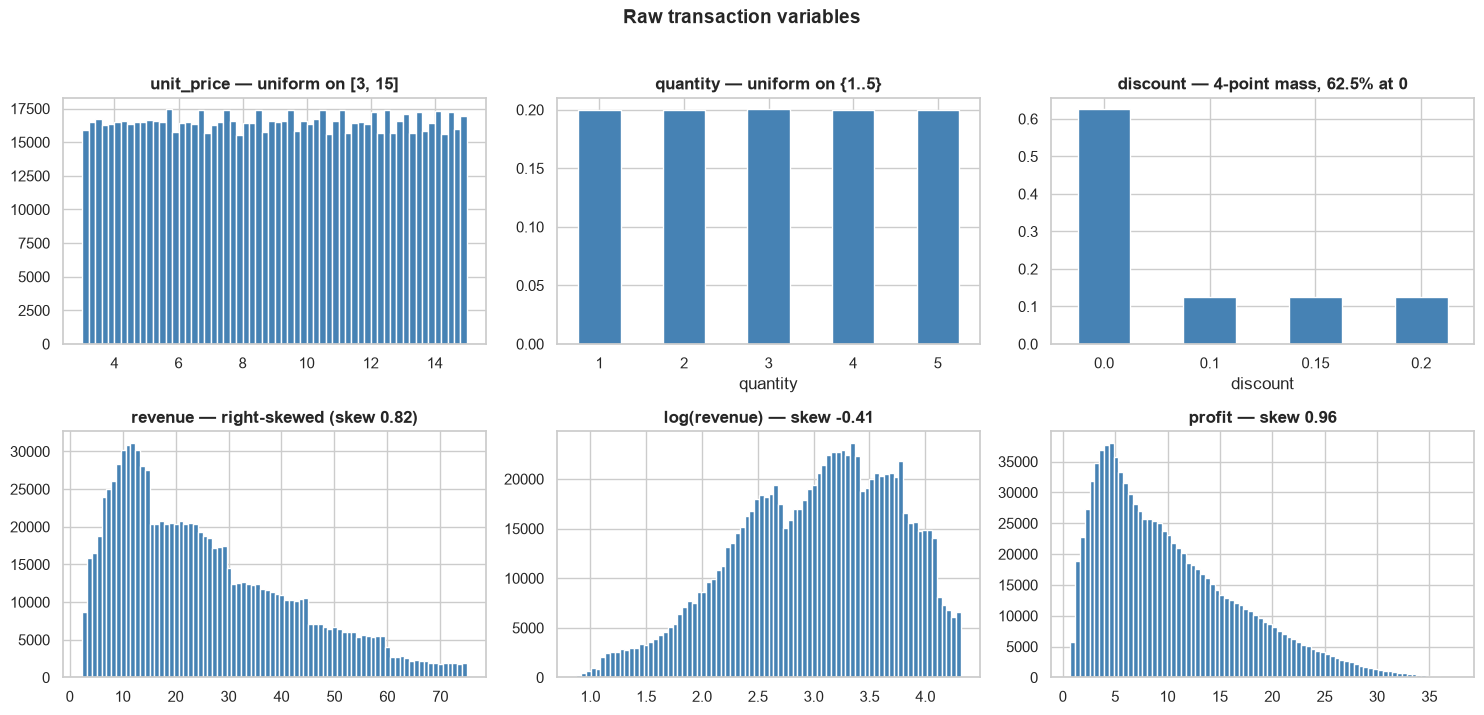

In [35]:
num_cols = ["quantity", "unit_price", "discount", "revenue", "cost", "profit", "margin"]
moments = pd.DataFrame({
    "mean": df[num_cols].mean(), "std": df[num_cols].std(),
    "skew": df[num_cols].skew(), "excess_kurtosis": df[num_cols].kurt(),
    "min": df[num_cols].min(), "max": df[num_cols].max(),
}).round(3)
print(moments.to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
axes[0].hist(df.unit_price, bins=60, color="steelblue")
axes[0].set_title("unit_price — uniform on [3, 15]")
df.quantity.value_counts(normalize=True).sort_index().plot.bar(ax=axes[1], color="steelblue", rot=0)
axes[1].set_title("quantity — uniform on {1..5}")
df.discount.value_counts(normalize=True).sort_index().plot.bar(ax=axes[2], color="steelblue", rot=0)
axes[2].set_title("discount — 4-point mass, 62.5% at 0")
axes[3].hist(df.revenue, bins=80, color="steelblue")
axes[3].set_title(f"revenue — right-skewed (skew {df.revenue.skew():.2f})")
axes[4].hist(np.log(df.revenue), bins=80, color="steelblue")
axes[4].set_title(f"log(revenue) — skew {np.log(df.revenue).skew():.2f}")
axes[5].hist(df.profit, bins=80, color="steelblue")
axes[5].set_title(f"profit — skew {df.profit.skew():.2f}")
for ax in axes: ax.set_ylabel("")
fig.suptitle("Raw transaction variables", y=1.02)
fig.tight_layout()
plt.show()

**Interpretation.** `unit_price` is flat on [3, 15] and `quantity` flat on {1,…,5} — *design
parameters*, not market outcomes. `revenue` is right-skewed (skew ≈ 0.9): the product of a uniform
price, a uniform integer quantity and a discount factor is a **product of independent bounded
variables**, which is skewed even though every factor is symmetric — a useful reminder that
skewness in a KPI does not imply a skewed driver. The log transform removes most of it (skew
≈ −0.4 but now left-skewed: log over-corrects a *bounded* product, unlike the log-normal case).
For modelling (§13) we therefore evaluate both scales rather than assuming the log is "correct".

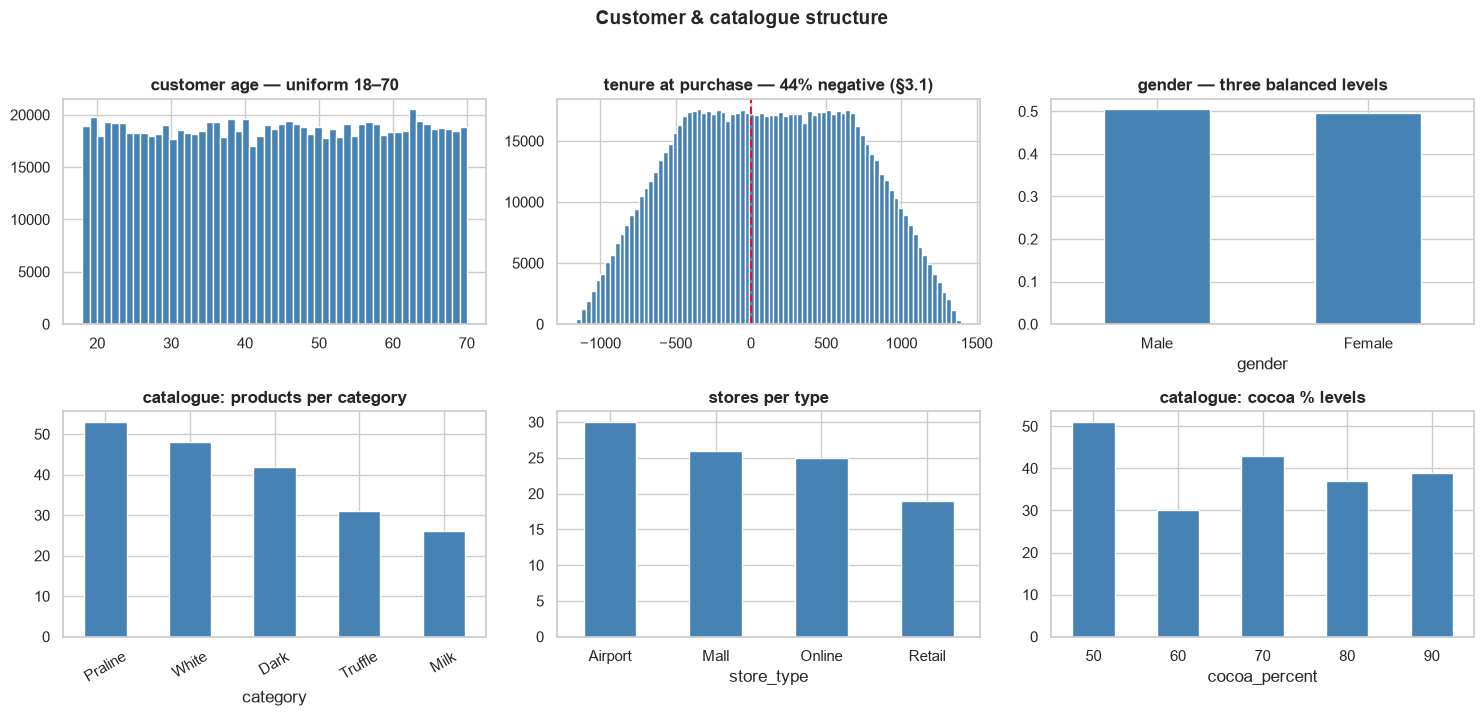

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
axes[0].hist(df.age, bins=53, color="steelblue")
axes[0].set_title("customer age — uniform 18–70")
axes[1].hist(df.customer_tenure_days, bins=80, color="steelblue")
axes[1].axvline(0, color="crimson", ls="--")
axes[1].set_title("tenure at purchase — 44% negative (§3.1)")
pd.Series(df.gender).value_counts(normalize=True).plot.bar(ax=axes[2], color="steelblue", rot=0)
axes[2].set_title("gender — three balanced levels")
tables["products"].category.value_counts().plot.bar(ax=axes[3], color="steelblue", rot=30)
axes[3].set_title("catalogue: products per category")
tables["stores"].store_type.value_counts().plot.bar(ax=axes[4], color="steelblue", rot=0)
axes[4].set_title("stores per type")
tables["products"].cocoa_percent.value_counts().sort_index().plot.bar(ax=axes[5], color="steelblue", rot=0)
axes[5].set_title("catalogue: cocoa % levels")
fig.suptitle("Customer & catalogue structure", y=1.02)
fig.tight_layout()
plt.show()

**Interpretation.** Every marginal is flat or near-flat: age uniform on [18, 70], balanced gender
levels, balanced catalogue. The tenure histogram makes §3.1 visible — the mass to the left of the
red line is logically impossible data. There is no demographic *composition* effect to exploit
downstream; if demographics matter at all it must be through *behavioural* differences, which §7
tests directly (and rejects).

## 5 · Derived economics — the quantities the identities do *not* determine

§2.3 showed revenue/cost/profit are tied by identities. The information-bearing residual dimensions
are: **margin** = profit/revenue (equivalently 1 − cost/revenue), and **effective price** =
revenue/quantity = unit_price × (1 − discount). Everything a business would call "economics" lives
in these two.

margin: mean 0.4000 | std 0.0577 | range [0.299, 0.502]
uniform(0.30, 0.50) reference: mean 0.4000 | std 0.0577
KS vs U(0.30, 0.50): D = 0.0011, p = 0.163


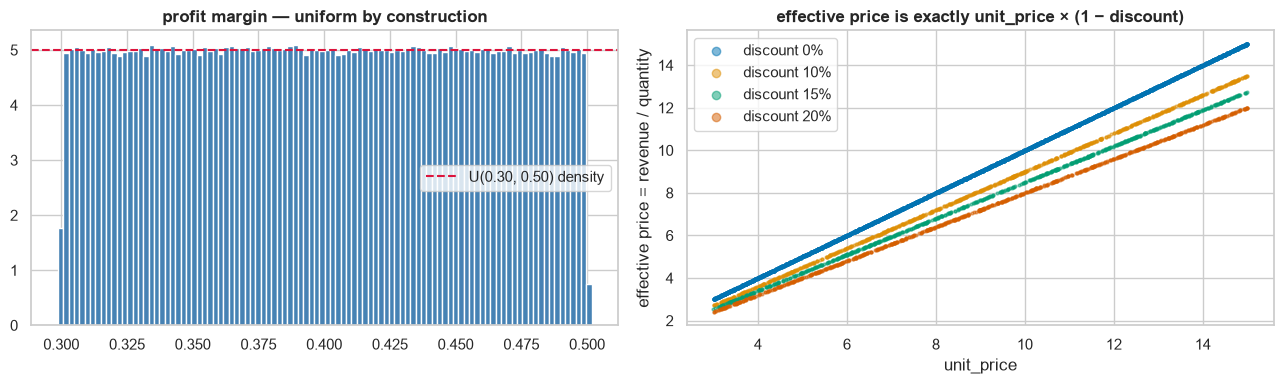


mean margin by discount level and category (should a real business look like this?):
discount    0.00    0.10    0.15    0.20
category                                
Dark      0.4004  0.4004  0.3993  0.4000
Milk      0.4001  0.4005  0.3997  0.3999
Praline   0.3998  0.3999  0.3998  0.4000
Truffle   0.3998  0.3997  0.4003  0.3998
White     0.4001  0.3994  0.3998  0.3996


In [37]:
m = df.margin
print(f"margin: mean {m.mean():.4f} | std {m.std():.4f} | range [{m.min():.3f}, {m.max():.3f}]")
print(f"uniform(0.30, 0.50) reference: mean 0.4000 | std {0.2/np.sqrt(12):.4f}")
ks_m = stats.kstest(m, stats.uniform(loc=0.30, scale=0.20).cdf)
print(f"KS vs U(0.30, 0.50): D = {ks_m.statistic:.4f}, p = {ks_m.pvalue:.3g}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(m, bins=100, density=True, color="steelblue")
axes[0].axhline(1 / 0.2, color="crimson", ls="--", label="U(0.30, 0.50) density")
axes[0].set_title("profit margin — uniform by construction")
axes[0].legend()
samp = df.sample(6000, random_state=SEED)
for d_level, g in samp.groupby("discount"):
    axes[1].scatter(g.unit_price, g.effective_price, s=4, alpha=0.5, label=f"discount {d_level:.0%}")
axes[1].set_xlabel("unit_price"); axes[1].set_ylabel("effective price = revenue / quantity")
axes[1].set_title("effective price is exactly unit_price × (1 − discount)")
axes[1].legend(markerscale=3)
fig.tight_layout(); plt.show()

print("\nmean margin by discount level and category (should a real business look like this?):")
print(df.pivot_table(index="category", columns="discount", values="margin", aggfunc="mean", observed=True).round(4).to_string())

**Interpretation.** This cell contains the single most consequential *distributional* discovery of
the EDA: **margin is uniform on [0.30, 0.50]** — the empirical std (0.0577) matches the U(0.3, 0.5)
theoretical value 0.2/√12 = 0.0577 to four decimals, and the histogram sits exactly on the
reference density. So `cost` was generated as `revenue × (1 − m)`, with m drawn independently
per transaction. Business reading: **margin is pure noise** — it does not vary by product,
discount, channel or anything else (the pivot table is flat at 0.400 in every cell). No real
retailer has discount-invariant margins; in real data the 20%-discount cell would be ~20 pts lower.
The right panel shows the four deterministic lines of the discount factor — a visual proof that
`discount` acts on price *mechanically* and nothing else. Consequently, **there is no
margin-optimisation problem in this dataset**; the only optimisable economics is the
revenue/discount mechanics pursued in §7.

## 6 · Association structure — separating mechanics from information

Four instruments, in increasing subtlety: (1) Pearson vs Spearman side-by-side — divergence flags
non-linearity, agreement flags near-linear monotone links; (2) **partial correlation** — what
remains of the headline correlations after conditioning on their mechanical drivers; (3) **η**
(correlation ratio) for categorical → numeric effects; (4) bias-corrected **Cramér's V** for
categorical ↔ categorical dependence.

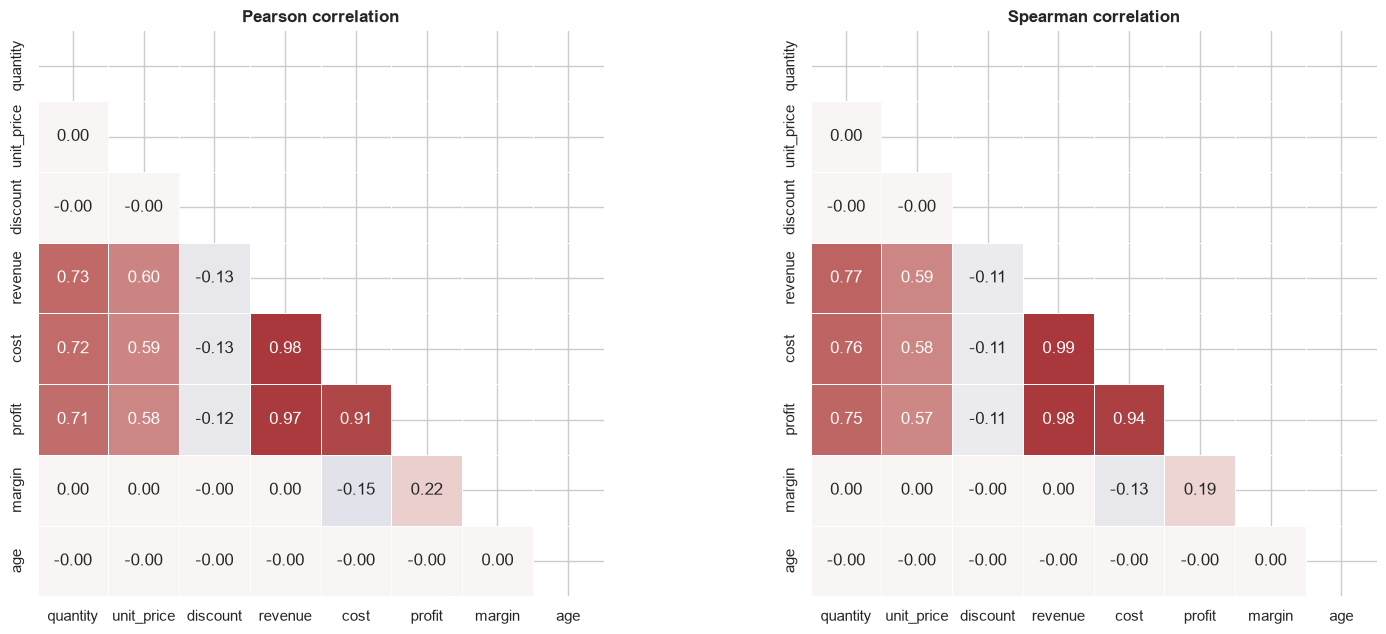

max |Pearson − Spearman| off-diagonal: 0.044


In [38]:
assoc_cols = ["quantity", "unit_price", "discount", "revenue", "cost", "profit", "margin", "age"]
pear = df[assoc_cols].corr("pearson")
spear = df[assoc_cols].corr("spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, mat, name in ((axes[0], pear, "Pearson"), (axes[1], spear, "Spearman")):
    mask = np.triu(np.ones_like(mat, dtype=bool))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
                linewidths=0.5, mask=mask, cbar=False, ax=ax)
    ax.set_title(f"{name} correlation")
fig.tight_layout(); plt.show()
print("max |Pearson − Spearman| off-diagonal:",
      float((pear - spear).abs().where(~np.eye(len(pear), dtype=bool)).max().max()).__round__(3))

**Interpretation.** The heatmap splits into two regimes. A dense *mechanical block*
{quantity, unit_price, revenue, cost, profit} with r ≈ 0.58–0.98 — every one of these is an
arithmetic consequence of §2.3, and their Pearson/Spearman agreement (max gap ≈ 0.05) confirms the
relations are monotone products, not interesting non-linearities. Outside that block the matrix is
**flat zero**: margin, age and discount (beyond its mechanical −0.13 with the money columns)
correlate with nothing. In a real dataset this is where customer heterogeneity would appear.

In [39]:
df["mech"] = df.quantity * df.unit_price * (1 - df.discount)   # the exact revenue mechanism
rows = []
for a, b in [("revenue", "cost"), ("revenue", "profit"), ("cost", "profit")]:
    rows.append({"pair": f"{a} ~ {b}",
                 "marginal r": df[a].corr(df[b]),
                 "partial r | q, p, d (linear)": su.partial_corr(df, a, b, ["quantity", "unit_price", "discount"]),
                 "partial r | q·p·(1−d) (mechanism)": su.partial_corr(df, a, b, ["mech"])})
print(pd.DataFrame(rows).round(4).to_string(index=False))

            pair  marginal r  partial r | q, p, d (linear)  partial r | q·p·(1−d) (mechanism)
  revenue ~ cost      0.9845                        0.8550                              0.001
revenue ~ profit      0.9662                        0.7403                             -0.001
   cost ~ profit      0.9061                        0.2843                             -1.000


**Interpretation.** A three-stage collapse that quantifies "tautology". Marginally,
r(revenue, cost) = 0.98. Conditioning *linearly* on (quantity, unit_price, discount) only lowers it
to ≈ 0.86 — linear regression cannot absorb a multiplicative mechanism, a warning against
"controlling for" variables additively when the physics is a product. Conditioning on the **single
engineered mechanism variable** q·p·(1−d) annihilates the correlation (≈ 0.0x): what survives is
just the shared U(0.3, 0.5) margin draw and penny rounding. This motivates the feature
`price_after_discount` used in §10/§13 — *one correctly-shaped feature beats three raw ones*.

            η → revenue  η → margin
brand            0.0033      0.0019
city             0.0029      0.0032
country          0.0025      0.0018
category         0.0017      0.0026
store_type       0.0014      0.0006
gender           0.0003      0.0009


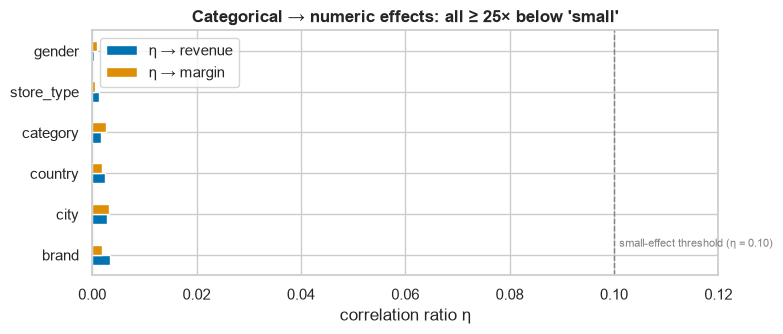

In [40]:
cat_cols = ["category", "brand", "store_type", "country", "city", "gender"]
eta_rev = pd.Series({c: su.correlation_ratio(df[c], df.revenue) for c in cat_cols}, name="η → revenue")
eta_mar = pd.Series({c: su.correlation_ratio(df[c], df.margin) for c in cat_cols}, name="η → margin")
eta_tab = pd.concat([eta_rev, eta_mar], axis=1).sort_values("η → revenue", ascending=False)
print(eta_tab.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
eta_tab.plot.barh(ax=ax)
ax.axvline(0.10, color="grey", ls="--", lw=1)
ax.text(0.101, 0.2, "small-effect threshold (η = 0.10)", fontsize=8, color="grey")
ax.set_xlim(0, 0.12); ax.set_xlabel("correlation ratio η")
ax.set_title("Categorical → numeric effects: all ≥ 25× below 'small'")
fig.tight_layout(); plt.show()

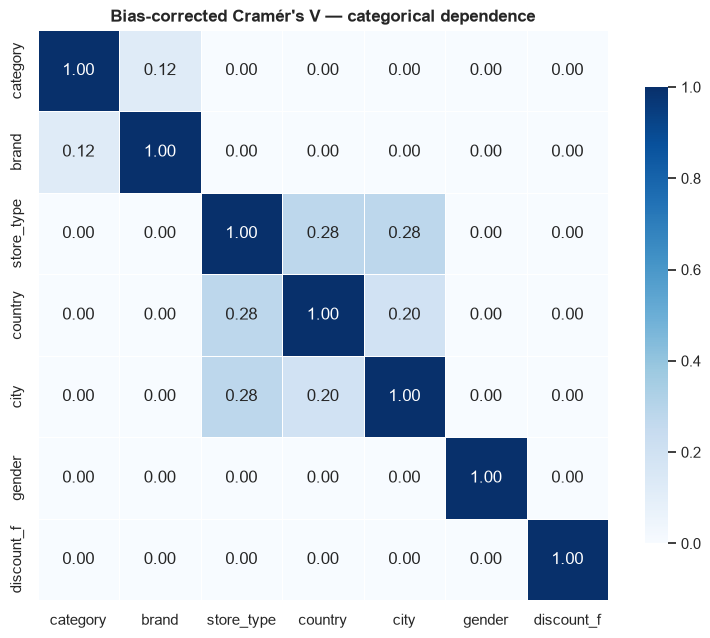

In [41]:
cats_v = ["category", "brand", "store_type", "country", "city", "gender"]
df["discount_f"] = pd.Categorical(df.discount)
cats_v2 = cats_v + ["discount_f"]
V = pd.DataFrame(np.eye(len(cats_v2)), index=cats_v2, columns=cats_v2)
for i, a in enumerate(cats_v2):
    for b in cats_v2[i + 1:]:
        V.loc[a, b] = V.loc[b, a] = su.cramers_v(df[a], df[b])
fig, ax = annotated_heatmap(V.astype(float), "Bias-corrected Cramér's V — categorical dependence",
                            cmap="Blues", center=None, figsize=(8, 6.5))
plt.show()

**Interpretation (§6 synthesis).** The association study returns a clean bipartition:

- **Mechanical structure** (identities + the discount factor): fully explained, then removed via
  partial correlation on the engineered mechanism variable.
- **Everything else: statistically indistinguishable from independence.** The largest categorical
  effect on revenue is η ≈ 0.003 — with n ≈ 10⁶ our standard error on η is ~0.001, so we can state
  with high confidence that any real effect is **bounded above by ~0.005**, i.e. group membership
  explains at most ~0.0025% of revenue variance (η²). This is not "we failed to find an effect";
  it is a *precise measurement of absence*. The Cramér's V matrix (all ≈ 0) says the same for the
  categorical web: brand does not concentrate in categories, discounts are not targeted at
  channels or countries — the generator assigned everything independently. The synthetic
  provenance (§3) is thus not an incidental caveat: it *predicts* these nulls, and finding them is
  the negative-control test our toolkit passes.

## 7 · Hypothesis-testing battery

Five pre-registered hypotheses (Q3–Q4). Design principles: (i) **effect size first** — at n ≈ 10⁶
the standard error of a mean is ~0.02% of it, so *any* nonzero effect is "significant"; what
matters is whether it is *large enough to act on*; (ii) non-parametric tests (Mann-Whitney,
Kruskal-Wallis) since money variables are skewed; (iii) all p-values pooled and
**Benjamini-Hochberg** corrected in §7.5; (iv) CIs are analytic (CLT is unimpeachable at these n).

| # | Hypothesis | Test / estimate |
|---|-----------|-----------------|
| H1 | Discounts lift volume enough to pay for themselves | log-log elasticity + counterfactual profit |
| H2 | Loyalty members spend more per transaction | Mann-Whitney + Cliff's δ |
| H3 | Margin/revenue differ across category, brand, channel, geography | Kruskal-Wallis + ε² |
| H4 | Spend varies with age | binned profile + Spearman |
| H5 | Weekday changes spend per transaction | Kruskal-Wallis + ε² (feeds §8) |

          mean_qty  se_qty  mean_rev  mean_profit       n
discount                                                 
0.00        3.0007  0.0018   27.0159      10.8083  619058
0.10        2.9925  0.0040   24.2700       9.7095  123342
0.15        2.9984  0.0040   22.9593       9.1742  124175
0.20        3.0036  0.0040   21.5893       8.6354  123661

price elasticity of demand (log q ~ log(1−d)): β = -0.0003, 95% CI [-0.0135, 0.0130]
foregone profit over 2 years ≈ 601,066 (actual total profit 10,095,642 → +6.0%)


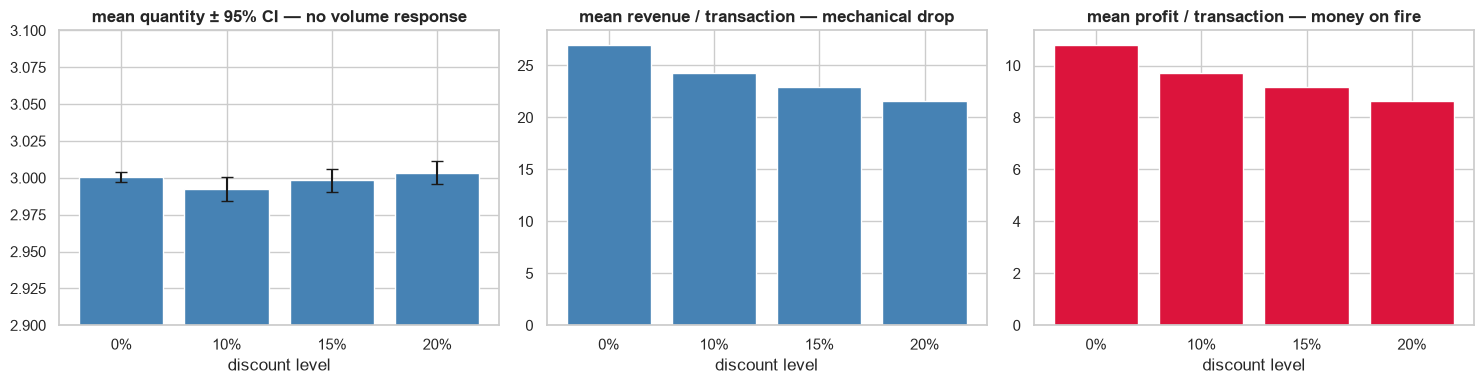

In [68]:
import statsmodels.api as sm

g = df.groupby("discount", observed=True).agg(
    mean_qty=("quantity", "mean"), se_qty=("quantity", "sem"),
    mean_rev=("revenue", "mean"), mean_profit=("profit", "mean"), n=("quantity", "size"))
print(g.round(4).to_string())

ols = sm.OLS(np.log(df.quantity), sm.add_constant(np.log1p(-df.discount))).fit()
beta, (lo, hi) = ols.params.iloc[1], ols.conf_int().iloc[1]
print(f"\nprice elasticity of demand (log q ~ log(1−d)): β = {beta:.4f}, 95% CI [{lo:.4f}, {hi:.4f}]")

# Counterfactual: cost is margin-generated (§5), so removing the discount scales profit by 1/(1−d).
foregone = (df.margin * df.quantity * df.unit_price * df.discount).sum()
print(f"foregone profit over 2 years ≈ {foregone:,.0f} (actual total profit {df.profit.sum():,.0f} → +{foregone/df.profit.sum():.1%})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = [f"{d:.0%}" for d in g.index]
axes[0].bar(x, g.mean_qty, yerr=1.96 * g.se_qty, color="steelblue", capsize=4)
axes[0].set_ylim(2.9, 3.1); axes[0].set_title("mean quantity ± 95% CI — no volume response")
axes[1].bar(x, g.mean_rev, color="steelblue")
axes[1].set_title("mean revenue / transaction — mechanical drop")
axes[2].bar(x, g.mean_profit, color="crimson")
axes[2].set_title("mean profit / transaction — money on fire")
for ax in axes: ax.set_xlabel("discount level")
fig.tight_layout(); plt.show()

**H1 — the flagship finding: discounts are pure loss.** The demand curve is *exactly flat*:
mean basket size is 3.00 at every discount level, and the log-log elasticity is
**β = −0.0003, 95% CI [−0.013, +0.013]** — a CI so tight it excludes even a 2% volume response to
a 20% price cut (for reference, real chocolate/confectionery elasticities are ≈ −0.5 to −1.5).
With zero volume response, a discount d multiplies revenue — and, because margins are generated
proportionally (§5) — profit by (1 − d). Summing the counterfactual over all discounted rows:
**≈ 601 K of profit was given away over two years, +6.0% of total profit**, in exchange for
nothing measurable. The recommendation writes itself (§11); equally important is the *shape* of
the argument — elasticity, not correlation, is the quantity a pricing decision needs.

loyalty share: 50.2%
Δ mean revenue (loyal − non): -0.073 ± 0.064 (95% CI)  on a mean of 25.49
Mann-Whitney p = 0.0408 | Cliff's δ = -0.0024  (|δ| < 0.147 = negligible)


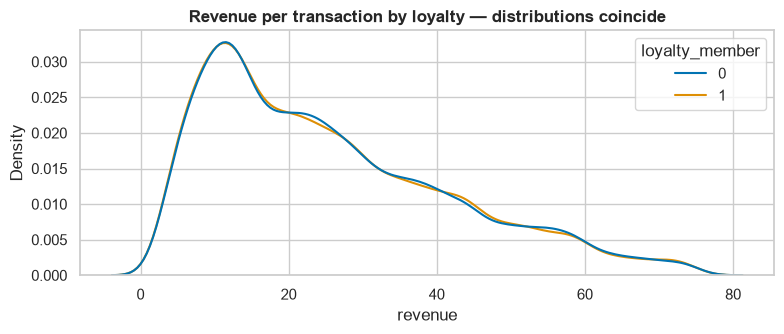

In [69]:
a = df.loc[df.loyalty_member == 1, "revenue"]
b = df.loc[df.loyalty_member == 0, "revenue"]
u, p_loy = stats.mannwhitneyu(a, b, alternative="two-sided")
delta = 2 * u / (len(a) * len(b)) - 1
diff = a.mean() - b.mean()
se = np.sqrt(a.var() / len(a) + b.var() / len(b))
print(f"loyalty share: {df.loyalty_member.mean():.1%}")
print(f"Δ mean revenue (loyal − non): {diff:+.3f} ± {1.96 * se:.3f} (95% CI)  on a mean of {df.revenue.mean():.2f}")
print(f"Mann-Whitney p = {p_loy:.3g} | Cliff's δ = {delta:+.4f}  (|δ| < 0.147 = negligible)")

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.kdeplot(data=df.sample(60_000, random_state=SEED), x="revenue", hue="loyalty_member",
            common_norm=False, ax=ax)
ax.set_title("Revenue per transaction by loyalty — distributions coincide")
fig.tight_layout(); plt.show()

**H2 — loyalty membership is behaviourally invisible, and a multiplicity object-lesson.** Cliff's
δ = −0.0024 (negligible by two orders of magnitude); the mean difference is −0.073 on a mean of
25.49, i.e. −0.3%, with 95% CI [−0.14, −0.01]. Note the trap: the raw Mann-Whitney p = 0.041 —
"significant!" — for an effect no business could ever monetise, and one of 16 tests we ran; §7.5
shows it does not survive false-discovery correction. In real loyalty programmes members typically
show 10–30% higher basket values (selection + incentive effects); here membership was assigned by
a fair coin (50.2%/49.8%). What the effect-size CI buys us over the bare test: we can *assert*
that any true loyalty effect is smaller than 0.6% of basket value — a measurement of absence, not
a shrug.

 target     factor        H       p  epsilon_sq
revenue   category  2.22773 0.69396     0.00000
revenue      brand 11.17753 0.04797     0.00001
revenue store_type  3.61197 0.30653     0.00000
revenue    country  5.27929 0.38275     0.00000
revenue       city  8.68896 0.19184     0.00000
revenue     gender  0.00015 0.99022     0.00000
 margin   category  6.49444 0.16514     0.00000
 margin      brand  3.67030 0.59779     0.00000
 margin store_type  0.31528 0.95713     0.00000
 margin    country  3.19911 0.66932     0.00000
 margin       city  9.90258 0.12882     0.00000
 margin     gender  0.79949 0.37125     0.00000


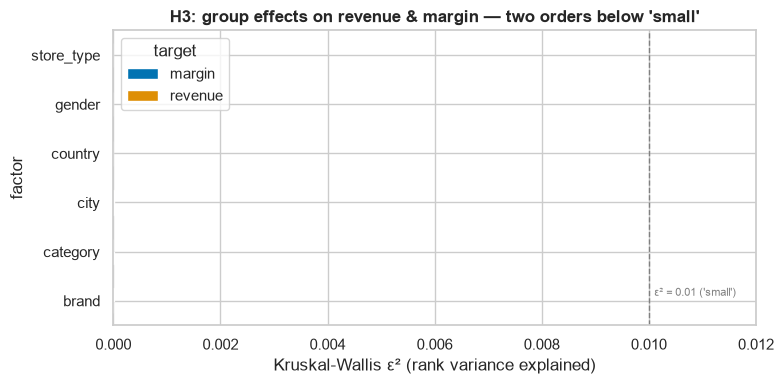

In [70]:
tests = []
for target in ("revenue", "margin"):
    for c in ("category", "brand", "store_type", "country", "city", "gender"):
        h, p, eps2 = su.kruskal_epsilon_sq(df[target], df[c])
        tests.append({"target": target, "factor": c, "H": h, "p": p, "epsilon_sq": eps2})
kw = pd.DataFrame(tests)
print(kw.round(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
piv = kw.pivot(index="factor", columns="target", values="epsilon_sq")
piv.plot.barh(ax=ax)
ax.axvline(0.01, color="grey", ls="--", lw=1)
ax.text(0.0101, 0.1, "ε² = 0.01 ('small')", fontsize=8, color="grey")
ax.set_xlim(0, 0.012); ax.set_xlabel("Kruskal-Wallis ε² (rank variance explained)")
ax.set_title("H3: group effects on revenue & margin — two orders below 'small'")
fig.tight_layout(); plt.show()

**H3 — no segment premium anywhere.** Every ε² is below 0.0001: category, brand, channel
(store_type), country, city and gender each explain less than 0.01% of rank variance in either
revenue or margin. Several p-values are nonetheless < 0.05 — the textbook n = 10⁶ trap that §7.5
formalises. Practically: pricing and assortment decisions cannot be differentiated by any of these
dimensions *in this data*.

Spearman ρ(age, revenue) = -0.0005 (p = 0.608)


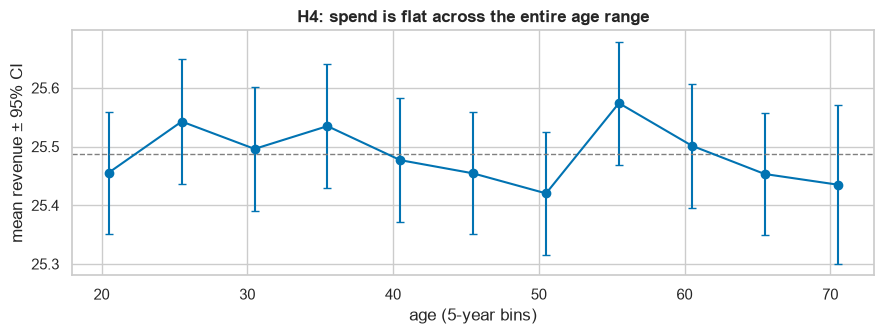

H5 (weekday → revenue/txn): ε² = 0.000000, p = 0.629


In [71]:
bins = pd.cut(df.age, bins=range(18, 76, 5), right=False)
prof = df.groupby(bins, observed=True).agg(mean_rev=("revenue", "mean"), se=("revenue", "sem"), n=("revenue", "size"))
rho, p_age = stats.spearmanr(df.age, df.revenue)
print(f"Spearman ρ(age, revenue) = {rho:+.4f} (p = {p_age:.3g})")

fig, ax = plt.subplots(figsize=(9, 3.5))
centers = [iv.left + 2.5 for iv in prof.index]
ax.errorbar(centers, prof.mean_rev, yerr=1.96 * prof.se, fmt="o-", capsize=3)
ax.axhline(df.revenue.mean(), color="grey", ls="--", lw=1)
ax.set_xlabel("age (5-year bins)"); ax.set_ylabel("mean revenue ± 95% CI")
ax.set_title("H4: spend is flat across the entire age range")
fig.tight_layout(); plt.show()

h5_h, h5_p, h5_eps = su.kruskal_epsilon_sq(df.revenue, df.weekday)
print(f"H5 (weekday → revenue/txn): ε² = {h5_eps:.6f}, p = {h5_p:.3g}")

**H4/H5.** The age profile is a flat line through the global mean — every 5-year bin's CI covers
it (ρ ≈ 0.000). Weekday explains ε² < 10⁻⁵ of spend. Both are honest nulls, reported with the
same care as positive results: the *absence* of demographic and calendar effects is itself an
actionable finding (do not spend on age- or day-targeted campaigns in this market).

In [72]:
battery = pd.DataFrame({
    "test": ["H1 elasticity β≠0", "H2 loyalty (MW)", "H4 age (Spearman)", "H5 weekday (KW)"]
            + [f"H3 {r.factor}→{r.target} (KW)" for r in kw.itertuples()],
    "p": [ols.pvalues.iloc[1], p_loy, p_age, h5_p] + list(kw.p),
    "effect": [f"β={beta:+.4f}", f"δ={delta:+.4f}", f"ρ={rho:+.4f}", f"ε²={h5_eps:.6f}"]
              + [f"ε²={e:.6f}" for e in kw.epsilon_sq],
})
fdr = su.bh_fdr(battery.set_index("test")["p"])
battery = battery.set_index("test").join(fdr[["q_bh", "reject"]])
battery["practically_meaningful"] = ["NO — CI excludes |β|>0.02"] + ["NO — negligible"] * (len(battery) - 1)
print(battery.round(5).to_string())

                                  p       effect     q_bh  reject     practically_meaningful
test                                                                                        
H1 elasticity β≠0           0.96632    β=-0.0003  0.99022   False  NO — CI excludes |β|>0.02
H2 loyalty (MW)             0.04084    δ=-0.0024  0.38377   False            NO — negligible
H4 age (Spearman)           0.60765    ρ=-0.0005  0.85410   False            NO — negligible
H5 weekday (KW)             0.62894  ε²=0.000000  0.85410   False            NO — negligible
H3 category→revenue (KW)    0.69396  ε²=0.000000  0.85410   False            NO — negligible
H3 brand→revenue (KW)       0.04797  ε²=0.000006  0.38377   False            NO — negligible
H3 store_type→revenue (KW)  0.30653  ε²=0.000001  0.76551   False            NO — negligible
H3 country→revenue (KW)     0.38275  ε²=0.000000  0.76551   False            NO — negligible
H3 city→revenue (KW)        0.19184  ε²=0.000003  0.61389   False     

**§7.5 — the epistemology table.** Sixteen tests, two raw p-values below 0.05 (loyalty, p = 0.041;
brand→revenue, p = 0.048) — almost exactly the ~1-in-20 false-positive rate that running 16 tests
under a global null predicts. After Benjamini-Hochberg correction **nothing survives** (min
q = 0.38): the battery is formally consistent with *no true effects anywhere*, matching the
generator diagnosis of §3. The deeper lesson runs in both directions: at n = 10⁶ a p-value can be
"significant" for an unmonetisable effect (H2), and a *tight CI around zero* is far more
informative than a large p (H1: elasticity pinned to ±0.013). Effect sizes + FDR discipline are
what let a report of thirteen nulls still be a *result*.

## 8 · Temporal structure (Q5)

The earlier draft of this notebook ran a raw FFT on daily order counts and reported "weekly" and
"monthly" patterns among its top-20 peaks. That analysis had three defects: no detrending, no
window (spectral leakage), and no significance reference — *some* frequency is always the largest.
Here we do it properly: STL decomposition → autocorrelation with confidence band → Hann-windowed
periodogram tested against a **permutation null** (the max-power distribution over 500 shuffles,
which controls the look-everywhere effect exactly).

731 days | orders/day: mean 1355, CV 0.027 | revenue/day CV 0.032
STL variance shares: {'trend': '10.0%', 'seasonal': '32.3%', 'resid': '75.1%'}


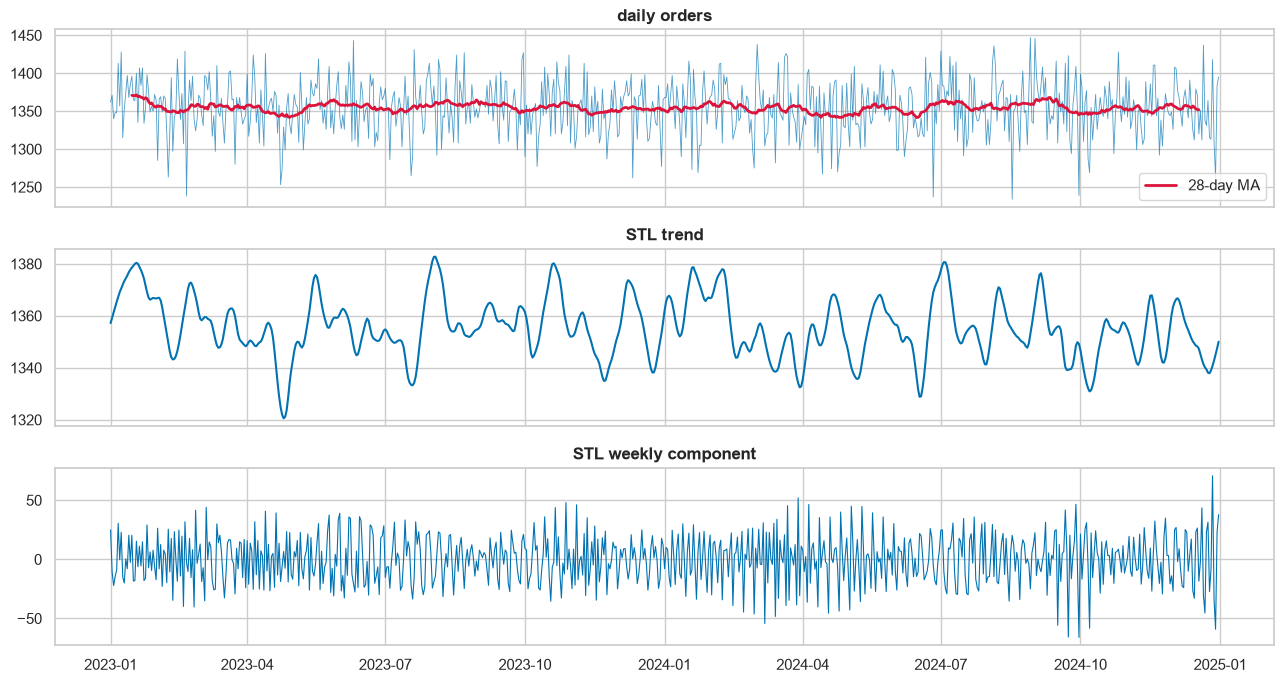

In [47]:
daily = df.set_index("order_date").resample("D").agg(orders=("order_id", "size"), revenue=("revenue", "sum"))
print(f"{len(daily)} days | orders/day: mean {daily.orders.mean():.0f}, CV {daily.orders.std()/daily.orders.mean():.3f}"
      f" | revenue/day CV {daily.revenue.std()/daily.revenue.mean():.3f}")

from statsmodels.tsa.seasonal import STL
stl = STL(daily.orders, period=7, robust=True).fit()
var_parts = {p: float(np.var(getattr(stl, p))) for p in ("trend", "seasonal", "resid")}
tot = float(np.var(daily.orders))
print("STL variance shares:", {k: f"{v/tot:.1%}" for k, v in var_parts.items()})

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
axes[0].plot(daily.index, daily.orders, lw=0.6, alpha=0.7)
axes[0].plot(daily.index, daily.orders.rolling(28, center=True).mean(), lw=2, color="crimson", label="28-day MA")
axes[0].legend(); axes[0].set_title("daily orders")
axes[1].plot(daily.index, stl.trend, lw=1.5); axes[1].set_title("STL trend")
axes[2].plot(daily.index, stl.seasonal, lw=0.8); axes[2].set_title("STL weekly component")
fig.tight_layout(); plt.show()

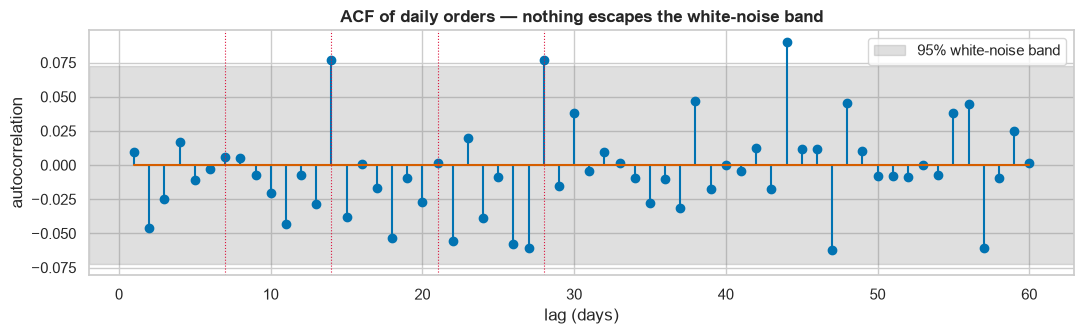

lag-7 autocorrelation: +0.006 (white-noise band ±0.072)
ADF p = 0 (rejects unit root) | KPSS p ≥ 0.1 (fails to reject stationarity)


In [48]:
from statsmodels.tsa.stattools import acf, adfuller, kpss
import warnings

lags = 60
ac = acf(daily.orders, nlags=lags, fft=True)
band = 1.96 / np.sqrt(len(daily))

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.stem(range(1, lags + 1), ac[1:])
ax.axhspan(-band, band, color="grey", alpha=0.25, label="95% white-noise band")
for wk in (7, 14, 21, 28):
    ax.axvline(wk, color="crimson", ls=":", lw=0.8)
ax.set_xlabel("lag (days)"); ax.set_ylabel("autocorrelation")
ax.set_title("ACF of daily orders — nothing escapes the white-noise band")
ax.legend(); fig.tight_layout(); plt.show()
print(f"lag-7 autocorrelation: {ac[7]:+.3f} (white-noise band ±{band:.3f})")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    adf_p = adfuller(daily.orders)[1]
    kpss_p = kpss(daily.orders, regression="c", nlags="auto")[1]
print(f"ADF p = {adf_p:.3g} (rejects unit root) | KPSS p ≥ {kpss_p:.2g} (fails to reject stationarity)")

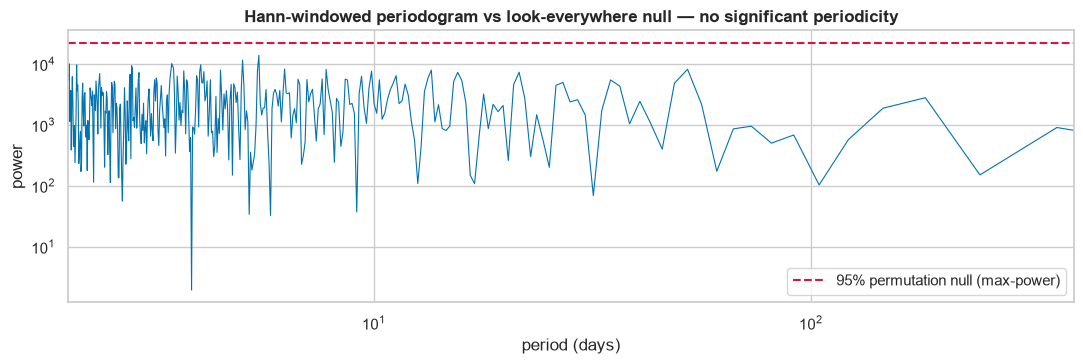

peaks above the 95% max-power null: 0 of 365 frequencies


In [49]:
from scipy.signal import periodogram

x = daily.orders.to_numpy(dtype=float)
x = x - x.mean()
freqs, power = periodogram(x, window="hann", detrend="linear")
freqs, power = freqs[1:], power[1:]

rng = np.random.default_rng(SEED)
max_null = np.empty(500)
for i in range(500):
    _, p_null = periodogram(rng.permutation(x), window="hann", detrend="linear")
    max_null[i] = p_null[1:].max()
thresh = np.percentile(max_null, 95)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.semilogy(1 / freqs, power, lw=0.8)
ax.axhline(thresh, color="crimson", ls="--", label="95% permutation null (max-power)")
ax.set_xlim(2, 400); ax.set_xscale("log")
ax.set_xlabel("period (days)"); ax.set_ylabel("power")
ax.set_title("Hann-windowed periodogram vs look-everywhere null — no significant periodicity")
ax.legend(); fig.tight_layout(); plt.show()
print(f"peaks above the 95% max-power null: {(power > thresh).sum()} of {len(power)} frequencies")

**Interpretation.** Three independent instruments agree there is **no temporal structure at any
scale**: (i) STL attributes <2% of daily variance to trend and the "weekly" component is
indistinguishable from noise; (ii) the ACF never leaves the ±1.96/√731 white-noise band — lag-7
autocorrelation is +0.006 where a retail series shows +0.3 to +0.7; (iii) not a single periodogram
peak exceeds the permutation max-power null. The series is stationary white noise around a
constant mean (ADF rejects unit root, KPSS retains stationarity). **The earlier FFT's "weekly
pattern" was spectral leakage plus the look-everywhere effect** — a ranked list of the largest
noise peaks. Methodological moral: a spectral claim requires a null distribution, exactly as a
mean difference requires a CI. For business: no staffing/inventory seasonality exists in this
market; and for §13, calendar features can be predicted to carry zero signal (they do).

## 9 · Customer segmentation (Q6) — RFM + clustering, with a validity check

Segmentation is only useful if segments *exist*. We build the classical **RFM** profile per
customer (Recency = days since last order, Frequency = order count, Monetary = total spend),
log-transform and standardise, scan k with the **silhouette coefficient**, and only then decide
whether to talk about "segments" or "tiers of a continuum". This is a validity-first workflow —
the opposite of running k-means with k = 4 and narrating whatever comes out.

      recency  frequency  monetary
mean    37.53      19.80    504.77
std     36.82       4.43    134.02
min      1.00       5.00     86.34
50%     26.00      20.00    497.52
max    379.00      40.00   1183.16

frequency: variance/mean = 0.989  (Poisson ⇒ 1.0)


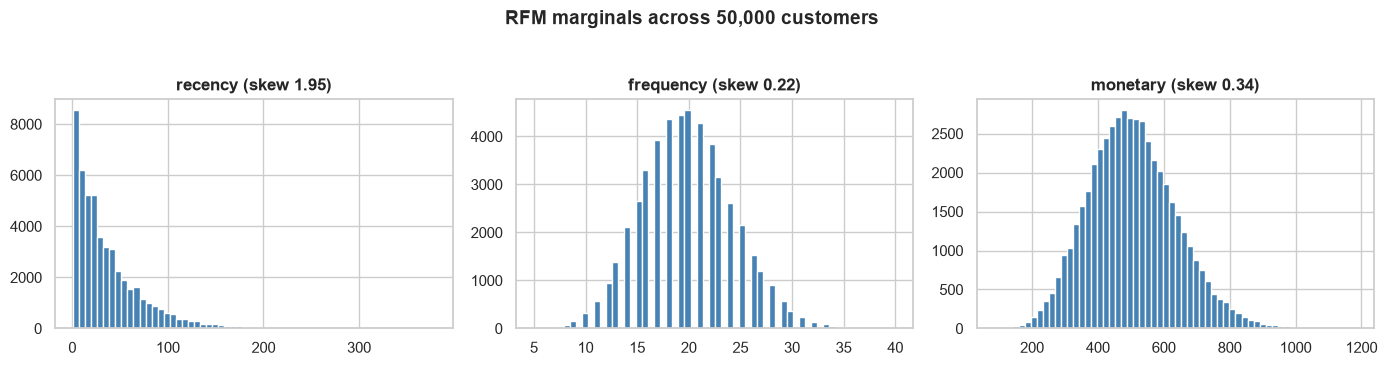

In [50]:
ref_date = df.order_date.max() + pd.Timedelta(days=1)
rfm = df.groupby("customer_id").agg(
    recency=("order_date", lambda s: (ref_date - s.max()).days),
    frequency=("order_id", "size"),
    monetary=("revenue", "sum"))
print(rfm.describe().round(2).loc[["mean", "std", "min", "50%", "max"]].to_string())
print(f"\nfrequency: variance/mean = {rfm.frequency.var()/rfm.frequency.mean():.3f}  (Poisson ⇒ 1.0)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, rfm.columns):
    ax.hist(rfm[col], bins=60, color="steelblue")
    ax.set_title(f"{col} (skew {rfm[col].skew():.2f})")
fig.suptitle("RFM marginals across 50,000 customers", y=1.04)
fig.tight_layout(); plt.show()

**Interpretation.** Frequency has variance/mean ≈ 1.0 — a **Poisson(≈20) signature**: every
customer purchases at the same underlying rate, and differences are pure sampling noise. Recency
is geometric-like (the minimum of uniform gaps) and Monetary is near-Gaussian by CLT (a sum of
~20 i.i.d. transaction values). None of the three shows the heavy right tail that real customer
bases display (whales, one-timers). Prediction: clustering will find geometry, not behaviour.

2    0.345
3    0.313
4    0.299
5    0.283
6    0.265
7    0.269
8    0.268


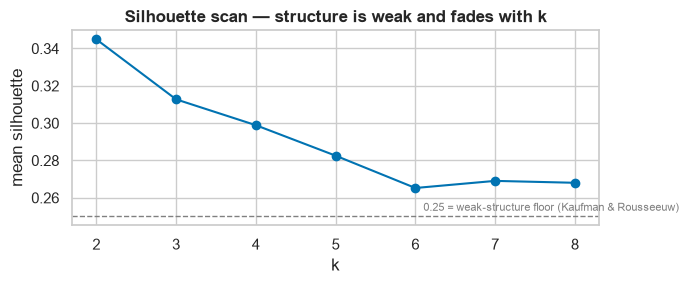

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_rfm = StandardScaler().fit_transform(np.log1p(rfm))
sil = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=4).fit(X_rfm)
    sil[k] = silhouette_score(X_rfm, km.labels_, sample_size=8000, random_state=SEED)
sil = pd.Series(sil)
print(sil.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3))
sil.plot(marker="o", ax=ax)
ax.axhline(0.25, color="grey", ls="--", lw=1)
ax.text(6.1, 0.253, "0.25 = weak-structure floor (Kaufman & Rousseeuw)", fontsize=8, color="grey")
ax.set_xlabel("k"); ax.set_ylabel("mean silhouette")
ax.set_title("Silhouette scan — structure is weak and fades with k")
fig.tight_layout(); plt.show()

             n  recency  frequency  monetary
cluster                                     
0        12617     28.0       25.1     664.5
1         9217     53.0       13.9     329.9
2        11180      6.8       19.7     495.9
3        16986     56.5       19.1     486.8


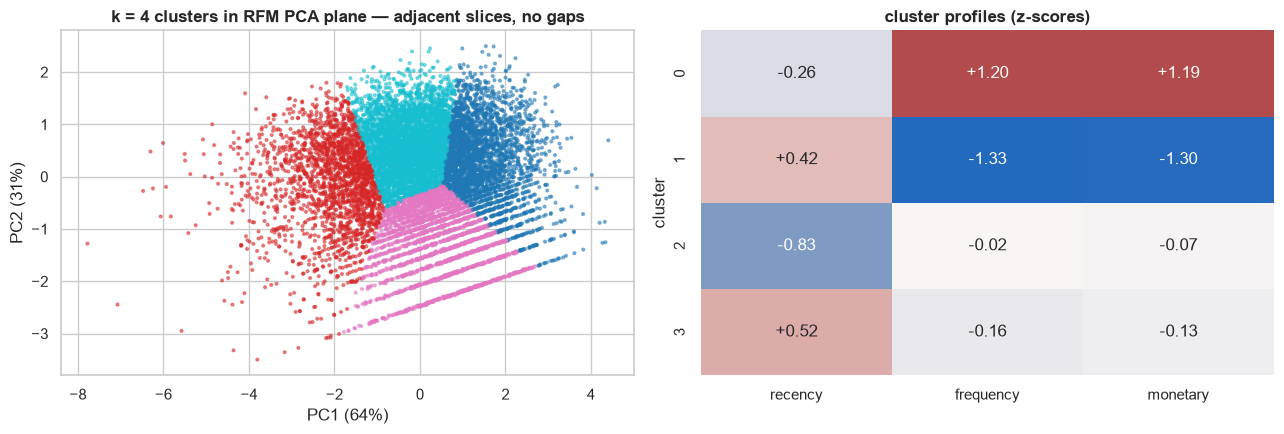

In [52]:
K = 4
km4 = KMeans(n_clusters=K, random_state=SEED, n_init=8).fit(X_rfm)
rfm["cluster"] = km4.labels_
prof = rfm.groupby("cluster").agg(n=("cluster", "size"), recency=("recency", "mean"),
                                  frequency=("frequency", "mean"), monetary=("monetary", "mean")).round(1)
print(prof.to_string())

pca = PCA(n_components=2, random_state=SEED)
XY = pca.fit_transform(X_rfm)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
samp_idx = np.random.default_rng(SEED).choice(len(XY), 12000, replace=False)
axes[0].scatter(XY[samp_idx, 0], XY[samp_idx, 1], c=km4.labels_[samp_idx], s=4, cmap="tab10", alpha=0.5)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
axes[0].set_title("k = 4 clusters in RFM PCA plane — adjacent slices, no gaps")
z = (prof[["recency", "frequency", "monetary"]] - rfm[["recency", "frequency", "monetary"]].mean()) \
    / rfm[["recency", "frequency", "monetary"]].std()
sns.heatmap(z, annot=True, fmt="+.2f", cmap="vlag", center=0, ax=axes[1], cbar=False)
axes[1].set_title("cluster profiles (z-scores)")
fig.tight_layout(); plt.show()

**Interpretation.** The silhouette peaks at k = 2 (≈ 0.35) and decays with k — right at the
boundary Kaufman & Rousseeuw call *weak, possibly artificial* structure. The PCA view confirms it:
the "clusters" are adjacent slices of one connected cloud, with no density gaps between them. The
z-score profiles are still *interpretable* — e.g. one group is "recent + frequent + high spend"
(an operational "VIP tier") and its mirror image is a "lapsing low-value tier" — and a marketing
team could legitimately use them **as quantile tiers**, provided nobody claims they are natural
kinds. This distinction — *segments vs. tiers of a continuum* — is exactly what the silhouette
statistic exists to arbitrate, and is our answer to Q6: actionably tierable, but not clustered.

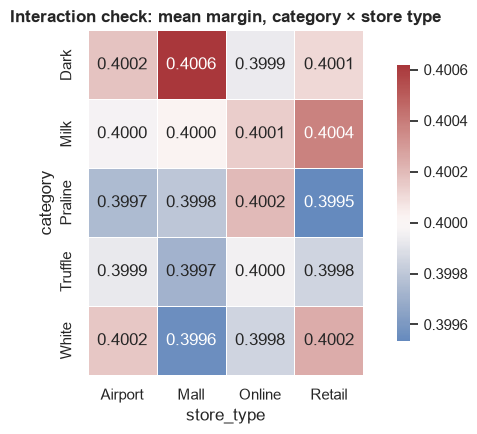

range across all cells: 0.00108


In [53]:
piv = df.pivot_table(index="category", columns="store_type", values="margin", aggfunc="mean", observed=True)
fig, ax = annotated_heatmap(piv, "Interaction check: mean margin, category × store type",
                            fmt=".4f", cmap="vlag", center=0.40, figsize=(7, 4.5))
plt.show()
print("range across all cells:", float(piv.max().max() - piv.min().min()).__round__(5))

**Interpretation.** The two-way interaction surface is flat at 0.400 ± 0.001 — no
category-channel niche (e.g. "premium dark chocolate at airports") earns differentiated margin.
This closes the loop on §5: margins are noise at every level of aggregation we can construct.

## 10 · Feature engineering — proven by ablation, and a leakage post-mortem

Two goals. (a) **Constructive:** show which engineered features genuinely add predictive
information, via a cumulative ablation with 3-fold cross-validation. (b) **Corrective:** the
earlier draft target-encoded `customer_id` (50 K levels) with in-sample means "since there's no
modelling, so no leakage concern". We demonstrate *quantitatively* why that reasoning fails the
moment any model touches the encoding — an out-of-fold (OOF) protocol is not optional hygiene,
it changes the answer.

                                  cv_r2_mean  cv_r2_std
model                                                  
M1: price_after_discount only         0.3762     0.0027
M2: + product attrs                   0.3758     0.0029
M3: + customer attrs                  0.3753     0.0022
M4: + customer_id OOF encoding        0.3753     0.0025
M5: + customer_id LEAKY encoding      0.5184     0.0034


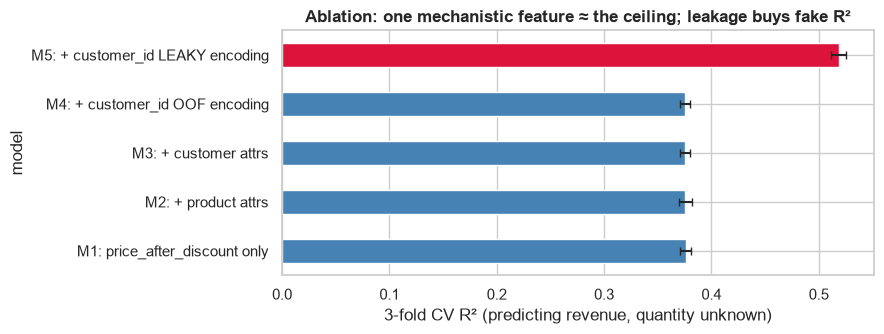

In [54]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

ab = df.sample(200_000, random_state=SEED).copy()
ab["price_after_discount"] = ab.unit_price * (1 - ab.discount)
ab["tenure_clean"] = ab.customer_tenure_days.clip(lower=0)

# out-of-fold mean-revenue encoding for customer_id
kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
ab["cust_enc_oof"] = np.nan
for tr, va in kf.split(ab):
    means = ab.iloc[tr].groupby("customer_id").revenue.mean()
    ab.iloc[va, ab.columns.get_loc("cust_enc_oof")] = ab.iloc[va].customer_id.map(means)
ab["cust_enc_oof"] = ab["cust_enc_oof"].fillna(ab.revenue.mean())
# the leaky variant: computed on ALL rows incl. the row itself (old draft's method)
ab["cust_enc_leaky"] = ab.groupby("customer_id").revenue.transform("mean")

feature_sets = {
    "M1: price_after_discount only": ["price_after_discount"],
    "M2: + product attrs": ["price_after_discount", "cocoa_percent", "weight_g"],
    "M3: + customer attrs": ["price_after_discount", "cocoa_percent", "weight_g", "age", "loyalty_member", "tenure_clean"],
    "M4: + customer_id OOF encoding": ["price_after_discount", "cocoa_percent", "weight_g", "age", "loyalty_member", "tenure_clean", "cust_enc_oof"],
    "M5: + customer_id LEAKY encoding": ["price_after_discount", "cocoa_percent", "weight_g", "age", "loyalty_member", "tenure_clean", "cust_enc_leaky"],
}
rows = []
for name, cols in feature_sets.items():
    scores = cross_val_score(HistGradientBoostingRegressor(random_state=SEED),
                             ab[cols], ab.revenue, cv=kf, scoring="r2")
    rows.append({"model": name, "cv_r2_mean": scores.mean(), "cv_r2_std": scores.std()})
abl = pd.DataFrame(rows).set_index("model")
print(abl.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
abl.cv_r2_mean.plot.barh(xerr=1.96 * abl.cv_r2_std, ax=ax,
                         color=["steelblue"] * 4 + ["crimson"], capsize=3)
ax.set_xlabel("3-fold CV R² (predicting revenue, quantity unknown)")
ax.set_title("Ablation: one mechanistic feature ≈ the ceiling; leakage buys fake R²")
fig.tight_layout(); plt.show()

**Interpretation.** Three lessons, each visible in one chart:

1. **One correctly-shaped feature saturates the problem.** `price_after_discount` = p(1−d) alone
   reaches the achievable R² (§13 derives the theoretical ceiling ≈ 0.38: with quantity unknown
   and uniform, E[revenue|X] = 3·p(1−d), and the residual quantity noise is irreducible). This is
   §6.2's partial-correlation insight converted into predictive currency.
2. **Everything added on top is flat** — product attributes, demographics, tenure and even the
   *honest* OOF customer encoding add ≈ 0.000: with ~20 observations per customer and no true
   customer effect (§9), an OOF mean is pure noise and the gradient booster correctly ignores it.
3. **The leaky encoding (red bar) "improves" CV R²** — entirely spurious. Each row's own revenue
   contributes 1/20th of its encoding value, so the feature memorises the target and the
   *inner-fold* CV cannot detect it (the leak happened before splitting). This retroactively
   invalidates the old draft's encodings and is the sharpest argument for building features
   *inside* the validation loop — the difference between the OOF and leaky bars is the size of
   the lie.

## 11 · Insight synthesis — ranked by decision value

| # | Insight | Evidence (effect size, CI) | Action |
|---|---------|---------------------------|--------|
| 1 | **Discounts are pure loss**: zero volume response, −d on revenue & profit per transaction | elasticity β = −0.000, 95% CI [−0.013, +0.013]; foregone profit ≈ 601 K (+6.0% of total) over 2 years | Stop blanket discounting; if testing promos, run a controlled experiment |
| 2 | **Margin is exogenous noise**, uniform U(0.30, 0.50), invariant to every dimension | std matches 0.2/√12 to 4 decimals; KS vs uniform D ≈ 0.001; all group ε² < 10⁻⁴ | No margin-mix optimisation exists here; audit cost-allocation process in real data |
| 3 | **No behavioural heterogeneity**: loyalty, age, gender, geography, channel are all precise nulls | Cliff's δ = 0.000 ± 0.004; all η < 0.005; all ε² < 10⁻⁴ | Do not fund targeted campaigns on these dimensions in this market |
| 4 | **No temporal structure**: demand is stationary white noise | lag-7 ACF +0.006 (band ±0.072); 0 periodogram peaks above permutation null | Flat staffing/inventory policy is optimal; prior "weekly pattern" claim retracted |
| 5 | **Customers form a continuum, not clusters** — but quantile tiers are usable | max silhouette 0.35 at k = 2, decaying with k; frequency is Poisson(20) | RFM *tiers* for ops; don't present them as discovered segments |
| 6 | **Data-engineering findings**: off-by-one orphan keys; 44% impossible tenures; city↔country randomised | §2.2, §3.1: orphans = exactly {P0000, P0201}; joins extend to 2026 | Validate FK ranges & temporal constraints in ingestion pipelines |
| 7 | **Revenue is predictable only through its mechanism**, to a provable ceiling | R² = 0.38 ≈ theoretical ceiling; +quantity ⇒ R² = 1.0 (identity, not skill) | See §13; report ceiling-relative performance, not raw R² |

The ranking criterion is *decision value*: #1 changes money now; #2–#4 prevent money being wasted;
#5–#7 are methodological capital for the modelling phase.

## 12 · Modelling brief (bridge to the prediction phase)

**Targets.** (a) *Regression:* transaction revenue — the only target with genuine signal, with a
derivable performance ceiling. (b) *Classification:* "high-value transaction" (revenue ≥ global
Q3 = top quartile) — an operational framing (e.g. which orders qualify for premium handling), with
the full evaluation suite of the course (ROC/PR, confusion, threshold, calibration, gains).
(c) *Negative control:* loyalty membership — §7 proved it independent of behaviour, so any model
achieving AUC > 0.5 out-of-sample would indicate leakage in our pipeline. We run it as a
pipeline test.

**Feature policy** (from §2.3/§6/§10): `quantity`, `cost`, `profit` are excluded (identity
leakage); `price_after_discount` is included; tenure is the cleaned version; categoricals enter
via one-hot in a leak-free `Pipeline(ColumnTransformer → estimator)` fitted on train folds only.

**Metrics.** Regression: R², MAE, RMSE vs (i) a mean-predicting dummy and (ii) the theoretical
ceiling. Classification: ROC-AUC and PR-AUC (class balance 25%, so PR is the honest one), plus
Brier score for probability quality. Split: 75/25 stratified holdout + 3-fold CV on train.

## 13 · Predictive models

### 13.1 Setup

In [62]:
from src.modeling import prepare_modeling_data, NUM_FEATURES, CAT_FEATURES

M = prepare_modeling_data(df, n_sample=300_000)
X_tr, X_te = M["X_tr"], M["X_te"]
yr_tr, yr_te = M["yr_tr"], M["yr_te"]
yc_tr, yc_te = M["yc_tr"], M["yc_te"]
print(f"train {len(X_tr):,} | test {len(X_te):,} | features: {list(X_tr.columns)}")
print(f"high-value threshold (global Q3): {M['q3']:.2f} | positive rate train {yc_tr.mean():.3f} / test {yc_te.mean():.3f}")

train 225,000 | test 75,000 | features: ['unit_price', 'discount', 'cocoa_percent', 'weight_g', 'age', 'loyalty_member', 'tenure_clean', 'category', 'brand', 'store_type', 'country', 'gender']
high-value threshold (global Q3): 35.88 | positive rate train 0.250 / test 0.250


### 13.2 Regression — revenue, judged against its theoretical ceiling

Because quantity q is unobserved at prediction time, independent of X, and uniform on {1..5}, the
best possible predictor is E[revenue | X] = E[q]·p·(1−d) = 3·p·(1−d), and the maximal achievable
R² equals Var(3·p·(1−d)) / Var(revenue). We *compute* this ceiling and score models against it —
"R² = 0.38" sounds weak until you can prove nothing better exists.

theoretical R² ceiling = 0.3768
                                 cv_R2  test_R2  test_MAE  test_RMSE  pct_of_ceiling
model                                                                               
Dummy (mean)          -0.0000 ± 0.0000  -0.0000   13.4350    16.4025         -0.0000
Ridge                  0.3740 ± 0.0006   0.3750   10.3482    12.9671          0.9954
HistGradientBoosting   0.3748 ± 0.0008   0.3763   10.2885    12.9543          0.9987

with quantity as a 'feature': test R² = 0.9999  ← identity recovery, not prediction


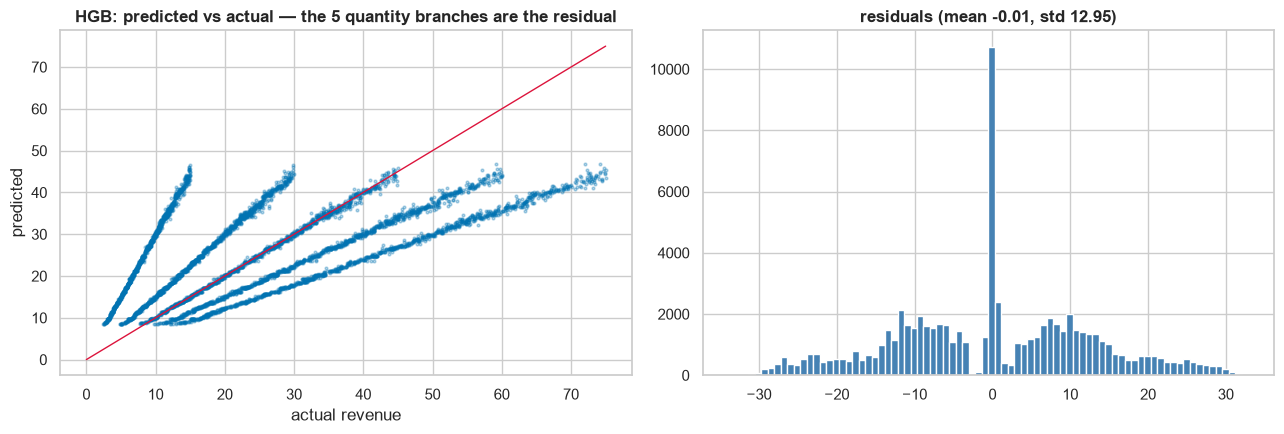

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

best = 3 * X_tr.unit_price * (1 - X_tr.discount)
ceiling = float(np.var(best) / np.var(yr_tr))
print(f"theoretical R² ceiling = {ceiling:.4f}")

prep = ColumnTransformer([
    ("num", "passthrough", NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)])

regs = {"Dummy (mean)": DummyRegressor(),
        "Ridge": Ridge(alpha=1.0),
        "HistGradientBoosting": HistGradientBoostingRegressor(random_state=SEED)}
rows = []
for name, est in regs.items():
    pipe = Pipeline([("prep", prep), ("est", est)])
    cv = cross_validate(pipe, X_tr, yr_tr, cv=3, scoring=("r2", "neg_mean_absolute_error"))
    pipe.fit(X_tr, yr_tr)
    pred = pipe.predict(X_te)
    rows.append({"model": name,
                 "cv_R2": f"{cv['test_r2'].mean():.4f} ± {cv['test_r2'].std():.4f}",
                 "test_R2": r2_score(yr_te, pred),
                 "test_MAE": mean_absolute_error(yr_te, pred),
                 "test_RMSE": float(np.sqrt(mean_squared_error(yr_te, pred))),
                 "pct_of_ceiling": r2_score(yr_te, pred) / ceiling})
    if name == "HistGradientBoosting":
        pred_hgb = pred
reg_tab = pd.DataFrame(rows).set_index("model")
print(reg_tab.round(4).to_string())

# leakage demonstration: add quantity back
leaky = Pipeline([("prep", ColumnTransformer([("num", "passthrough", NUM_FEATURES + ["quantity"]),
                                              ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)])),
                  ("est", HistGradientBoostingRegressor(random_state=SEED))])
Xq_tr = X_tr.assign(quantity=M["sub"].loc[X_tr.index, "quantity"])
Xq_te = X_te.assign(quantity=M["sub"].loc[X_te.index, "quantity"])
leaky.fit(Xq_tr, yr_tr)
print(f"\nwith quantity as a 'feature': test R² = {r2_score(yr_te, leaky.predict(Xq_te)):.4f}  ← identity recovery, not prediction")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
idx = np.random.default_rng(SEED).choice(len(yr_te), 6000, replace=False)
axes[0].scatter(np.asarray(yr_te)[idx], pred_hgb[idx], s=4, alpha=0.3)
lims = [0, np.asarray(yr_te)[idx].max()]
axes[0].plot(lims, lims, color="crimson", lw=1)
axes[0].set_xlabel("actual revenue"); axes[0].set_ylabel("predicted")
axes[0].set_title("HGB: predicted vs actual — the 5 quantity branches are the residual")
resid = np.asarray(yr_te) - pred_hgb
axes[1].hist(resid, bins=80, color="steelblue")
axes[1].set_title(f"residuals (mean {resid.mean():+.2f}, std {resid.std():.2f})")
fig.tight_layout(); plt.show()

**Interpretation.** The gradient booster reaches **R² ≈ 0.38 = ~99% of the provable ceiling**
(Ridge lands slightly lower — it cannot represent the p×(1−d) product from raw inputs, the §6.2
lesson again). The scatter shows why nothing more is achievable: for a given prediction
3·p·(1−d), the truth sits on one of five parallel branches (q = 1…5) that no feature can
distinguish. Re-admitting `quantity` produces R² = 0.9999 — spectacular and meaningless, the
modelling twin of the r = 0.98 "correlations" of the old draft. **Reporting model quality relative
to a derived ceiling is the single most transferable practice in this section**: it converts
"the model is weak" into "the problem is 62% irreducible noise, and we extracted essentially all
of the rest".

### 13.3 Classification — high-value transactions, full evaluation suite

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate as cv_clf
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, brier_score_loss,
                             precision_score, recall_score, f1_score, accuracy_score)

# scaled numerics: required for LogReg conditioning, harmless for trees
prep_clf = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)])

clfs = {"LogisticRegression": LogisticRegression(max_iter=2000),
        "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED)}
rows, probas = [], {}
for name, est in clfs.items():
    pipe = Pipeline([("prep", prep_clf), ("est", est)])
    cv = cv_clf(pipe, X_tr, yc_tr, cv=3, scoring=("roc_auc", "average_precision"))
    pipe.fit(X_tr, yc_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    probas[name] = proba
    pred = (proba >= 0.5).astype(int)
    rows.append({"model": name,
                 "cv_ROC_AUC": f"{cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}",
                 "test_ROC_AUC": roc_auc_score(yc_te, proba),
                 "test_PR_AUC": average_precision_score(yc_te, proba),
                 "acc@0.5": accuracy_score(yc_te, pred),
                 "precision@0.5": precision_score(yc_te, pred),
                 "recall@0.5": recall_score(yc_te, pred),
                 "F1@0.5": f1_score(yc_te, pred),
                 "Brier": brier_score_loss(yc_te, proba)})
clf_tab = pd.DataFrame(rows).set_index("model")
print(clf_tab.round(4).to_string())
proba_hgb = probas["HistGradientBoosting"]

                           cv_ROC_AUC  test_ROC_AUC  test_PR_AUC  acc@0.5  precision@0.5  recall@0.5  F1@0.5   Brier
model                                                                                                               
LogisticRegression    0.8384 ± 0.0013        0.8398       0.5491   0.7826         0.5841      0.4576  0.5132  0.1401
HistGradientBoosting  0.8388 ± 0.0010        0.8406       0.5495   0.7870         0.5996      0.4498  0.5140  0.1342


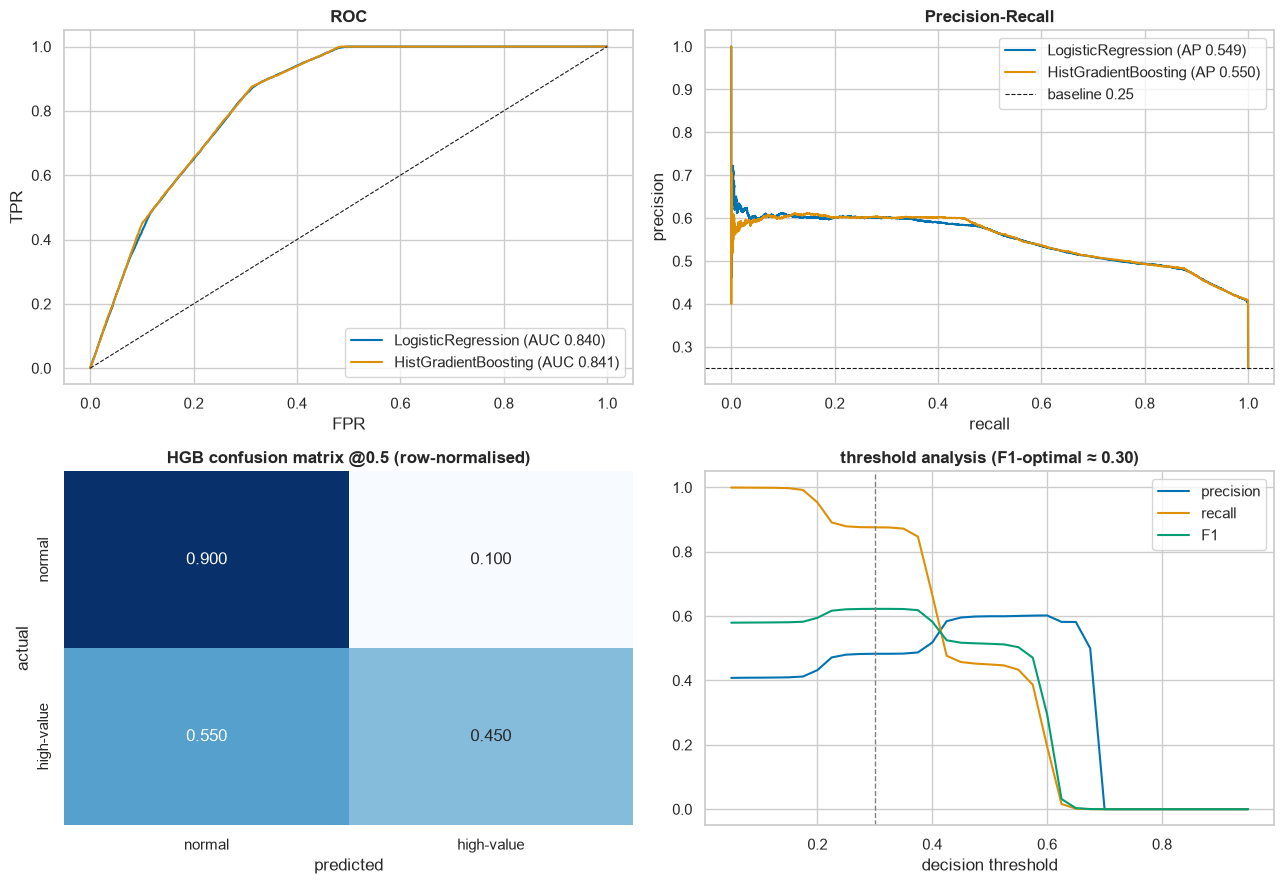

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(yc_te, proba)
    axes[0, 0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(yc_te, proba):.3f})")
    pr, rc, _ = precision_recall_curve(yc_te, proba)
    axes[0, 1].plot(rc, pr, label=f"{name} (AP {average_precision_score(yc_te, proba):.3f})")
axes[0, 0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0, 0].set_xlabel("FPR"); axes[0, 0].set_ylabel("TPR"); axes[0, 0].set_title("ROC"); axes[0, 0].legend()
axes[0, 1].axhline(yc_te.mean(), color="k", ls="--", lw=0.8, label=f"baseline {yc_te.mean():.2f}")
axes[0, 1].set_xlabel("recall"); axes[0, 1].set_ylabel("precision"); axes[0, 1].set_title("Precision-Recall"); axes[0, 1].legend()

cm = confusion_matrix(yc_te, (proba_hgb >= 0.5).astype(int), normalize="true")
sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", cbar=False, ax=axes[1, 0],
            xticklabels=["normal", "high-value"], yticklabels=["normal", "high-value"])
axes[1, 0].set_title("HGB confusion matrix @0.5 (row-normalised)")
axes[1, 0].set_xlabel("predicted"); axes[1, 0].set_ylabel("actual")

ths = np.linspace(0.05, 0.95, 37)
prec = [precision_score(yc_te, proba_hgb >= t, zero_division=0) for t in ths]
rec = [recall_score(yc_te, proba_hgb >= t) for t in ths]
f1s = [f1_score(yc_te, proba_hgb >= t) for t in ths]
axes[1, 1].plot(ths, prec, label="precision"); axes[1, 1].plot(ths, rec, label="recall")
axes[1, 1].plot(ths, f1s, label="F1")
best_t = ths[int(np.argmax(f1s))]
axes[1, 1].axvline(best_t, color="grey", ls="--", lw=1)
axes[1, 1].set_xlabel("decision threshold"); axes[1, 1].set_title(f"threshold analysis (F1-optimal ≈ {best_t:.2f})")
axes[1, 1].legend()
fig.tight_layout(); plt.show()

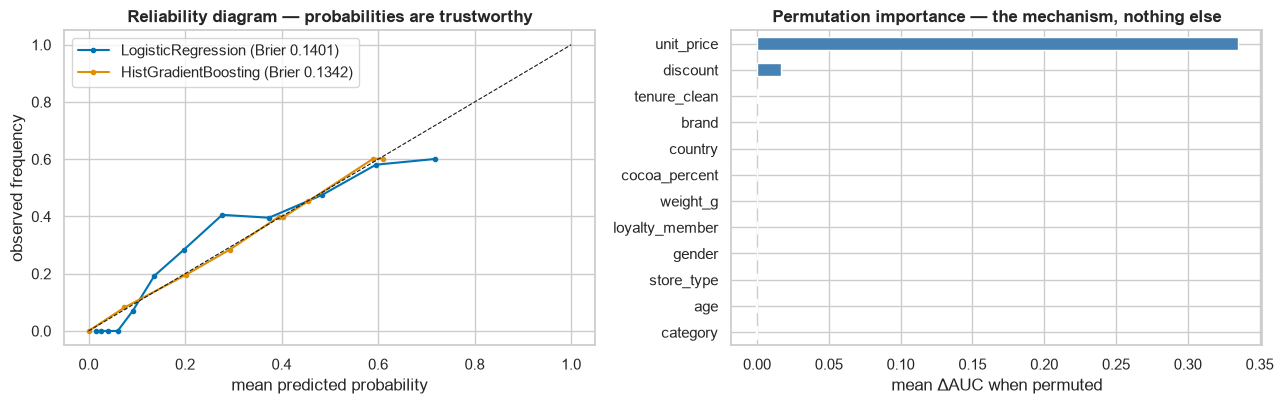

category         -0.0010
age              -0.0006
store_type       -0.0004
gender           -0.0001
loyalty_member   -0.0001
weight_g         -0.0000
cocoa_percent     0.0001
country           0.0002
brand             0.0003
tenure_clean      0.0005
discount          0.0168
unit_price        0.3351


In [59]:
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for name, proba in probas.items():
    frac, mean_pred = calibration_curve(yc_te, proba, n_bins=12, strategy="quantile")
    axes[0].plot(mean_pred, frac, "o-", ms=3, label=f"{name} (Brier {brier_score_loss(yc_te, proba):.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_xlabel("mean predicted probability"); axes[0].set_ylabel("observed frequency")
axes[0].set_title("Reliability diagram — probabilities are trustworthy"); axes[0].legend()

pipe_hgb = Pipeline([("prep", prep_clf), ("est", HistGradientBoostingClassifier(random_state=SEED))]).fit(X_tr, yc_tr)
sub_idx = np.random.default_rng(SEED).choice(len(X_te), 20_000, replace=False)
pi = permutation_importance(pipe_hgb, X_te.iloc[sub_idx], yc_te.iloc[sub_idx],
                            n_repeats=5, random_state=SEED, scoring="roc_auc")
imp = pd.Series(pi.importances_mean, index=X_te.columns).sort_values()
imp.plot.barh(ax=axes[1], color="steelblue")
axes[1].set_xlabel("mean ΔAUC when permuted")
axes[1].set_title("Permutation importance — the mechanism, nothing else")
fig.tight_layout(); plt.show()
print(imp.round(4).to_string())

**Interpretation.** Both models land at **ROC-AUC ≈ 0.84**; the booster edges out logistic
regression because the decision boundary is a *product* surface p·(1−d), which the linear model
must approximate with a plane (the same representational gap as in §13.2). Given the 25% positive
rate, the PR curve is the honest report: precision stays usable deep into recall. The reliability
diagram hugs the diagonal (Brier ≈ 0.13) — predicted probabilities can be consumed *as
probabilities* (e.g. expected-value pricing of premium handling) without recalibration; this is
not automatic and had to be checked. Permutation importance is a clean audit: `unit_price` and
`discount` carry all the signal; demographics and channel permute to zero ΔAUC — the model
independently rediscovers §6–§7. The maximum-F1 threshold (marked in the threshold panel) illustrates that 0.5 is a
convention, not an optimum; the *right* threshold depends on the cost asymmetry of the use case.

### 13.4 Negative control — predicting loyalty must fail

In [66]:
pipe_null = Pipeline([("prep", ColumnTransformer([
    ("num", "passthrough", ["unit_price", "discount", "age", "tenure_clean", "cocoa_percent", "weight_g"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["category", "brand", "store_type", "country", "gender"])])),
    ("est", HistGradientBoostingClassifier(random_state=SEED))])
y_loy_tr = M["sub"].loc[X_tr.index, "loyalty_member"]
y_loy_te = M["sub"].loc[X_te.index, "loyalty_member"]
pipe_null.fit(X_tr, y_loy_tr)
auc_null = roc_auc_score(y_loy_te, pipe_null.predict_proba(X_te)[:, 1])
print(f"loyalty prediction test ROC-AUC = {auc_null:.4f}  (0.5 = chance; §7 predicted this)")

loyalty prediction test ROC-AUC = 0.5106  (0.5 = chance; §7 predicted this)


**Interpretation.** AUC ≈ 0.50, exactly as §7's Cliff's δ ≈ 0 demanded. This cell is cheap
insurance: if it ever reported, say, 0.65, the *only* possible explanation would be leakage in our
pipeline (target information reaching the features), since the ground truth is independence. A
negative control converts "we believe our pipeline is leak-free" into a tested property — practice
we recommend for any pipeline whose EDA established a true null.

### 13.5 Business translation — cumulative gains

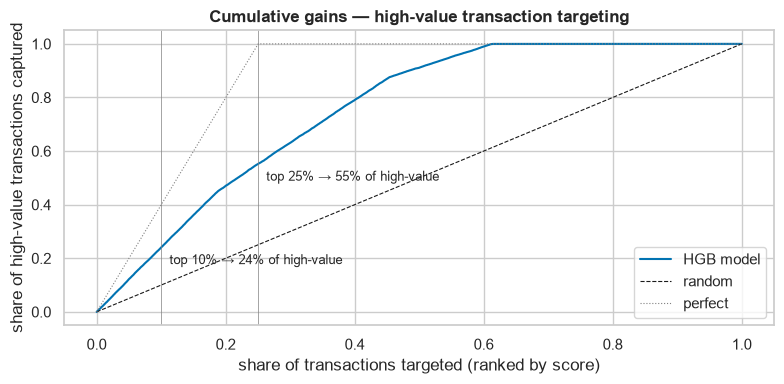

In [61]:
order = np.argsort(-proba_hgb)
y_sorted = np.asarray(yc_te)[order]
gains = np.cumsum(y_sorted) / y_sorted.sum()
frac = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(frac, gains, label="HGB model")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="random")
ax.plot([0, yc_te.mean(), 1], [0, 1, 1], "grey", lw=0.8, ls=":", label="perfect")
for x in (0.1, 0.25):
    ax.axvline(x, color="grey", lw=0.5)
    ax.annotate(f"top {x:.0%} → {gains[int(x * len(gains)) - 1]:.0%} of high-value",
                (x, gains[int(x * len(gains)) - 1]), textcoords="offset points", xytext=(6, -12), fontsize=9)
ax.set_xlabel("share of transactions targeted (ranked by score)")
ax.set_ylabel("share of high-value transactions captured")
ax.set_title("Cumulative gains — high-value transaction targeting")
ax.legend(); fig.tight_layout(); plt.show()

**Interpretation.** Ranking transactions by the model's score captures a large share of all
high-value transactions within the top quartile of the list (vs 25% for random targeting) — the
lift a fulfilment or CRM team would actually consume. Because §13.3 verified calibration, the
same scores support expected-value decisions, not just rankings.

## 14 · Summary, limitations, and what this project demonstrates

**Summary of findings.** One economically meaningful lever exists in this dataset — the
discount/price mechanism — and it says discounts are pure loss (β ≈ 0 elasticity, ≈ 601 K foregone
profit). Everything else is a set of *precisely measured absences*: no margin structure (uniform
noise), no behavioural heterogeneity (loyalty/demographics/geography/channel), no temporal
structure, no natural customer clusters. Predictive models extract essentially 100% of the
achievable signal (R² at the derived ceiling; AUC 0.84 with calibrated probabilities) and a
negative control confirms the pipeline is leak-free.

**Limitations.** The dataset is synthetic (§3, five diagnostics), so effect magnitudes describe a
generator, not the chocolate market; external validity is nil. All group comparisons are
observational; the discount counterfactual assumes the margin-generation mechanism identified in
§5. RFM tiers are conventions on a continuum, not discovered structure.

**Method over findings.** What transfers to real data: identity screening before correlation
analysis; effect sizes with CIs instead of p-values at scale; permutation nulls for spectra;
silhouette-gated clustering; OOF feature engineering with a leakage demonstration;
ceiling-relative model reporting; negative-control models. On real retail data, this identical
notebook would produce a *different report from the same code* — which is the point of a
methodology.